# **EDA 1.0 NOTEBOOK**
by jack phelan ^_^

In [26]:
#imports
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv('../data/interim/1.0-initial-cleaned-data.csv', keep_default_na=False)

display(df.head())

,patient_id,age,gender,ethnicity,hospital_id,height_m,smoker,bmi,weight_kg,adjusted_weight_kg,has_diabetes,has_hypertension,exercise_frequency,diet_type,number_of_prior_visits,medications_prescribed,length_of_stay,type_of_treatment,target
0,1000000,23,Female,African American,Hosp2,1.6,False,25.0,64.0,63.283346,False,False,Regular,High-fat,3.0,3.0,0,None,0
1,1000002,56,Female,Hispanic,Hosp3,1.8,True,27.0,87.5,87.678859,False,False,Regular,High-fat,2.0,,2,None,0
2,1000003,28,Male,African American,Hosp1,1.8,False,35.0,113.4,113.497844,False,True,None,Other,,2.0,5,None,0
3,1000004,70,Female,Caucasian,Hosp2,1.8,False,27.7,89.7,89.717694,False,False,None,Other,3.0,,0,Major Surgery,0
4,1000005,48,Female,Hispanic,Hosp1,1.9,False,22.4,80.9,80.528927,False,False,Occasional,High-fat,7.0,5.0,7,Major Surgery,1


In [28]:
ids = df['patient_id']
target = df['target']

features_df = df.drop(columns=['target', 'patient_id'])

## **DISTRIBUTION/OUTLIERS ANALYSIS**

In [29]:
# plots


def set_theme():
    sns.set_theme(
        style="whitegrid",
        context="talk",
        palette="flare",
        rc={
            "axes.titlesize": 14,
            "axes.labelsize": 12,
            "figure.dpi": 120,
        },
    )


def plot_formatting_helper(
    column_name,
    ax,
    title_suffix,
    y_label,
    rotate_x_threshold=None,
    n_items=None,
):
    """
    helper for formatting count-style plots (barplots, histograms with count stat, etc)
    with consistent titles, axis labels, grid, and optional x-axis rotation for long category names
    """
    pretty_name = column_name.replace("_", " ").title()
    ax.set_title(f"{pretty_name} {title_suffix}", pad=12, weight="bold")
    ax.set_xlabel(pretty_name)
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

    if (
        rotate_x_threshold is not None
        and n_items is not None
        and n_items > rotate_x_threshold
    ):
        ax.tick_params(axis="x", rotation=35)


def plot_histogram(
    df,
    column_name,
    bins="auto",
    stat="count",
    kde=False,
    show_bin_counts=False,
    kde_color="#0f4c81",
    ax=None,
):
    """
    make a histogram of a selected column (distribution)
    options for bins, stat type (count, density, etc), kde overlay, and showing bin counts
    """
    created_fig = None
    if ax is None:
        created_fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column_name,
        bins=bins,
        stat=stat,
        kde=kde,
        line_kws={"linewidth": 2},
        color=sns.color_palette("flare")[2],
        edgecolor="white",
        linewidth=1,
        alpha=0.9,
        ax=ax,
    )

    # Force KDE line styling after plot creation for consistent behavior.
    if kde and ax.lines:
        ax.lines[-1].set_color(kde_color)
        ax.lines[-1].set_linewidth(2.2)

    y_label = "Count" if stat == "count" else stat.title()
    plot_formatting_helper(
        column_name=column_name,
        ax=ax,
        title_suffix="Distribution",
        y_label=y_label,
    )
    ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

    if show_bin_counts:
        for patch in ax.patches:
            height = patch.get_height()
            if height > 0:
                ax.annotate(
                    f"{height:,.0f}",
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha="center",
                    va="bottom",
                    textcoords="offset points",
                    xytext=(0, 4),
                    fontsize=9,
                    color="#2f2f2f",
                )

    if created_fig is not None:
        created_fig.tight_layout()
        return created_fig, ax

    return ax.figure, ax


def plot_barplot(
    df,
    column_name,
    show_bin_counts=True,
    top_n=None,
    order="desc",
    palette="flare",
    single_color=None,
    ax=None,
):
    """
    make barplot of a selected column (value counts)
    can optionally show bin counts, order by count, and choose color scheme
    """
    plot_df = df.copy()

    # confirm column exists
    if column_name not in plot_df.columns:
        raise ValueError(f"Column '{column_name}' not found in dataframe")

    # get value counts of column for graphing
    val_counts = (
        plot_df[column_name]
        .astype("string")
        .fillna("Missing")
        .value_counts(dropna=False)
        .rename_axis(column_name)
        .reset_index(name="count")
    )

    # optional order of value counts
    if order == "asc":
        val_counts = val_counts.sort_values("count", ascending=True)
    else:
        val_counts = val_counts.sort_values("count", ascending=False)

    if top_n is not None:
        val_counts = val_counts.head(top_n)

    created_fig = None
    if ax is None:
        created_fig, ax = plt.subplots(figsize=(8, 5))

    sns.barplot(
        data=val_counts,
        x=column_name,
        y="count",
        color=single_color if single_color is not None else "#9f86c0",
        edgecolor="white",
        linewidth=1,
        ax=ax,
    )

    # Apply one color per bar from the chosen palette.
    if single_color is None:
        bar_colors = sns.color_palette(palette, n_colors=len(ax.patches))
        for patch, color in zip(ax.patches, bar_colors):
            patch.set_facecolor(color)

    # call helper to make the graph look nicer
    plot_formatting_helper(
        column_name=column_name,
        ax=ax,
        title_suffix="Counts",
        y_label="Count",
        rotate_x_threshold=8,
        n_items=len(val_counts),
    )

    # add bin counts if declared
    if show_bin_counts:
        for patch in ax.patches:
            height = patch.get_height()
            if height > 0:
                ax.annotate(
                    f"{height:,.0f}",
                    (patch.get_x() + patch.get_width() / 2, height),
                    ha="center",
                    va="bottom",
                    textcoords="offset points",
                    xytext=(0, 4),
                    fontsize=9,
                    color="#2f2f2f",
                )

    if created_fig is not None:
        created_fig.tight_layout()
        return created_fig, ax

    return ax.figure, ax


def plot_grid(
    df,
    column_names,
    plot_func,
    n_plot_cols=2,
    sharex=False,
    sharey=False,
    figsize_scale=(8, 5),
    **plot_kwargs,
):
    """Generic grid renderer for any plotting function that accepts df, column_name, and ax."""
    n_plots = len(column_names)
    n_rows = (n_plots - 1) // n_plot_cols + 1

    fig, axes = plt.subplots(
        n_rows,
        n_plot_cols,
        figsize=(figsize_scale[0] * n_plot_cols, figsize_scale[1] * n_rows),
        sharex=sharex,
        sharey=sharey,
    )

    axes = np.array(axes).reshape(-1)

    for i, column_name in enumerate(column_names):
        plot_func(
            df=df,
            column_name=column_name,
            ax=axes[i],
            **plot_kwargs,
        )

    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig, axes[:n_plots]


def plot_barplot_grid(
    df,
    column_names,
    show_bin_counts=True,
    top_n=None,
    order="desc",
    palette="flare",
    single_color=None,
    n_plot_cols=2,
    sharey=False,
):
    """Backwards-compatible wrapper around the generic plot_grid for barplots."""
    return plot_grid(
        df=df,
        column_names=column_names,
        plot_func=plot_barplot,
        n_plot_cols=n_plot_cols,
        sharey=sharey,
        show_bin_counts=show_bin_counts,
        top_n=top_n,
        order=order,
        palette=palette,
        single_color=single_color,
    )

(<Figure size 2880x3000 with 14 Axes>,
 array([<Axes: title={'center': 'Hospital Id Counts'}, xlabel='Hospital Id', ylabel='Count'>,
        <Axes: title={'center': 'Gender Counts'}, xlabel='Gender', ylabel='Count'>,
        <Axes: title={'center': 'Smoker Counts'}, xlabel='Smoker', ylabel='Count'>,
        <Axes: title={'center': 'Has Diabetes Counts'}, xlabel='Has Diabetes', ylabel='Count'>,
        <Axes: title={'center': 'Has Hypertension Counts'}, xlabel='Has Hypertension', ylabel='Count'>,
        <Axes: title={'center': 'Exercise Frequency Counts'}, xlabel='Exercise Frequency', ylabel='Count'>,
        <Axes: title={'center': 'Diet Type Counts'}, xlabel='Diet Type', ylabel='Count'>,
        <Axes: title={'center': 'Number Of Prior Visits Counts'}, xlabel='Number Of Prior Visits', ylabel='Count'>,
        <Axes: title={'center': 'Medications Prescribed Counts'}, xlabel='Medications Prescribed', ylabel='Count'>,
        <Axes: title={'center': 'Length Of Stay Counts'}, xlabel='Len

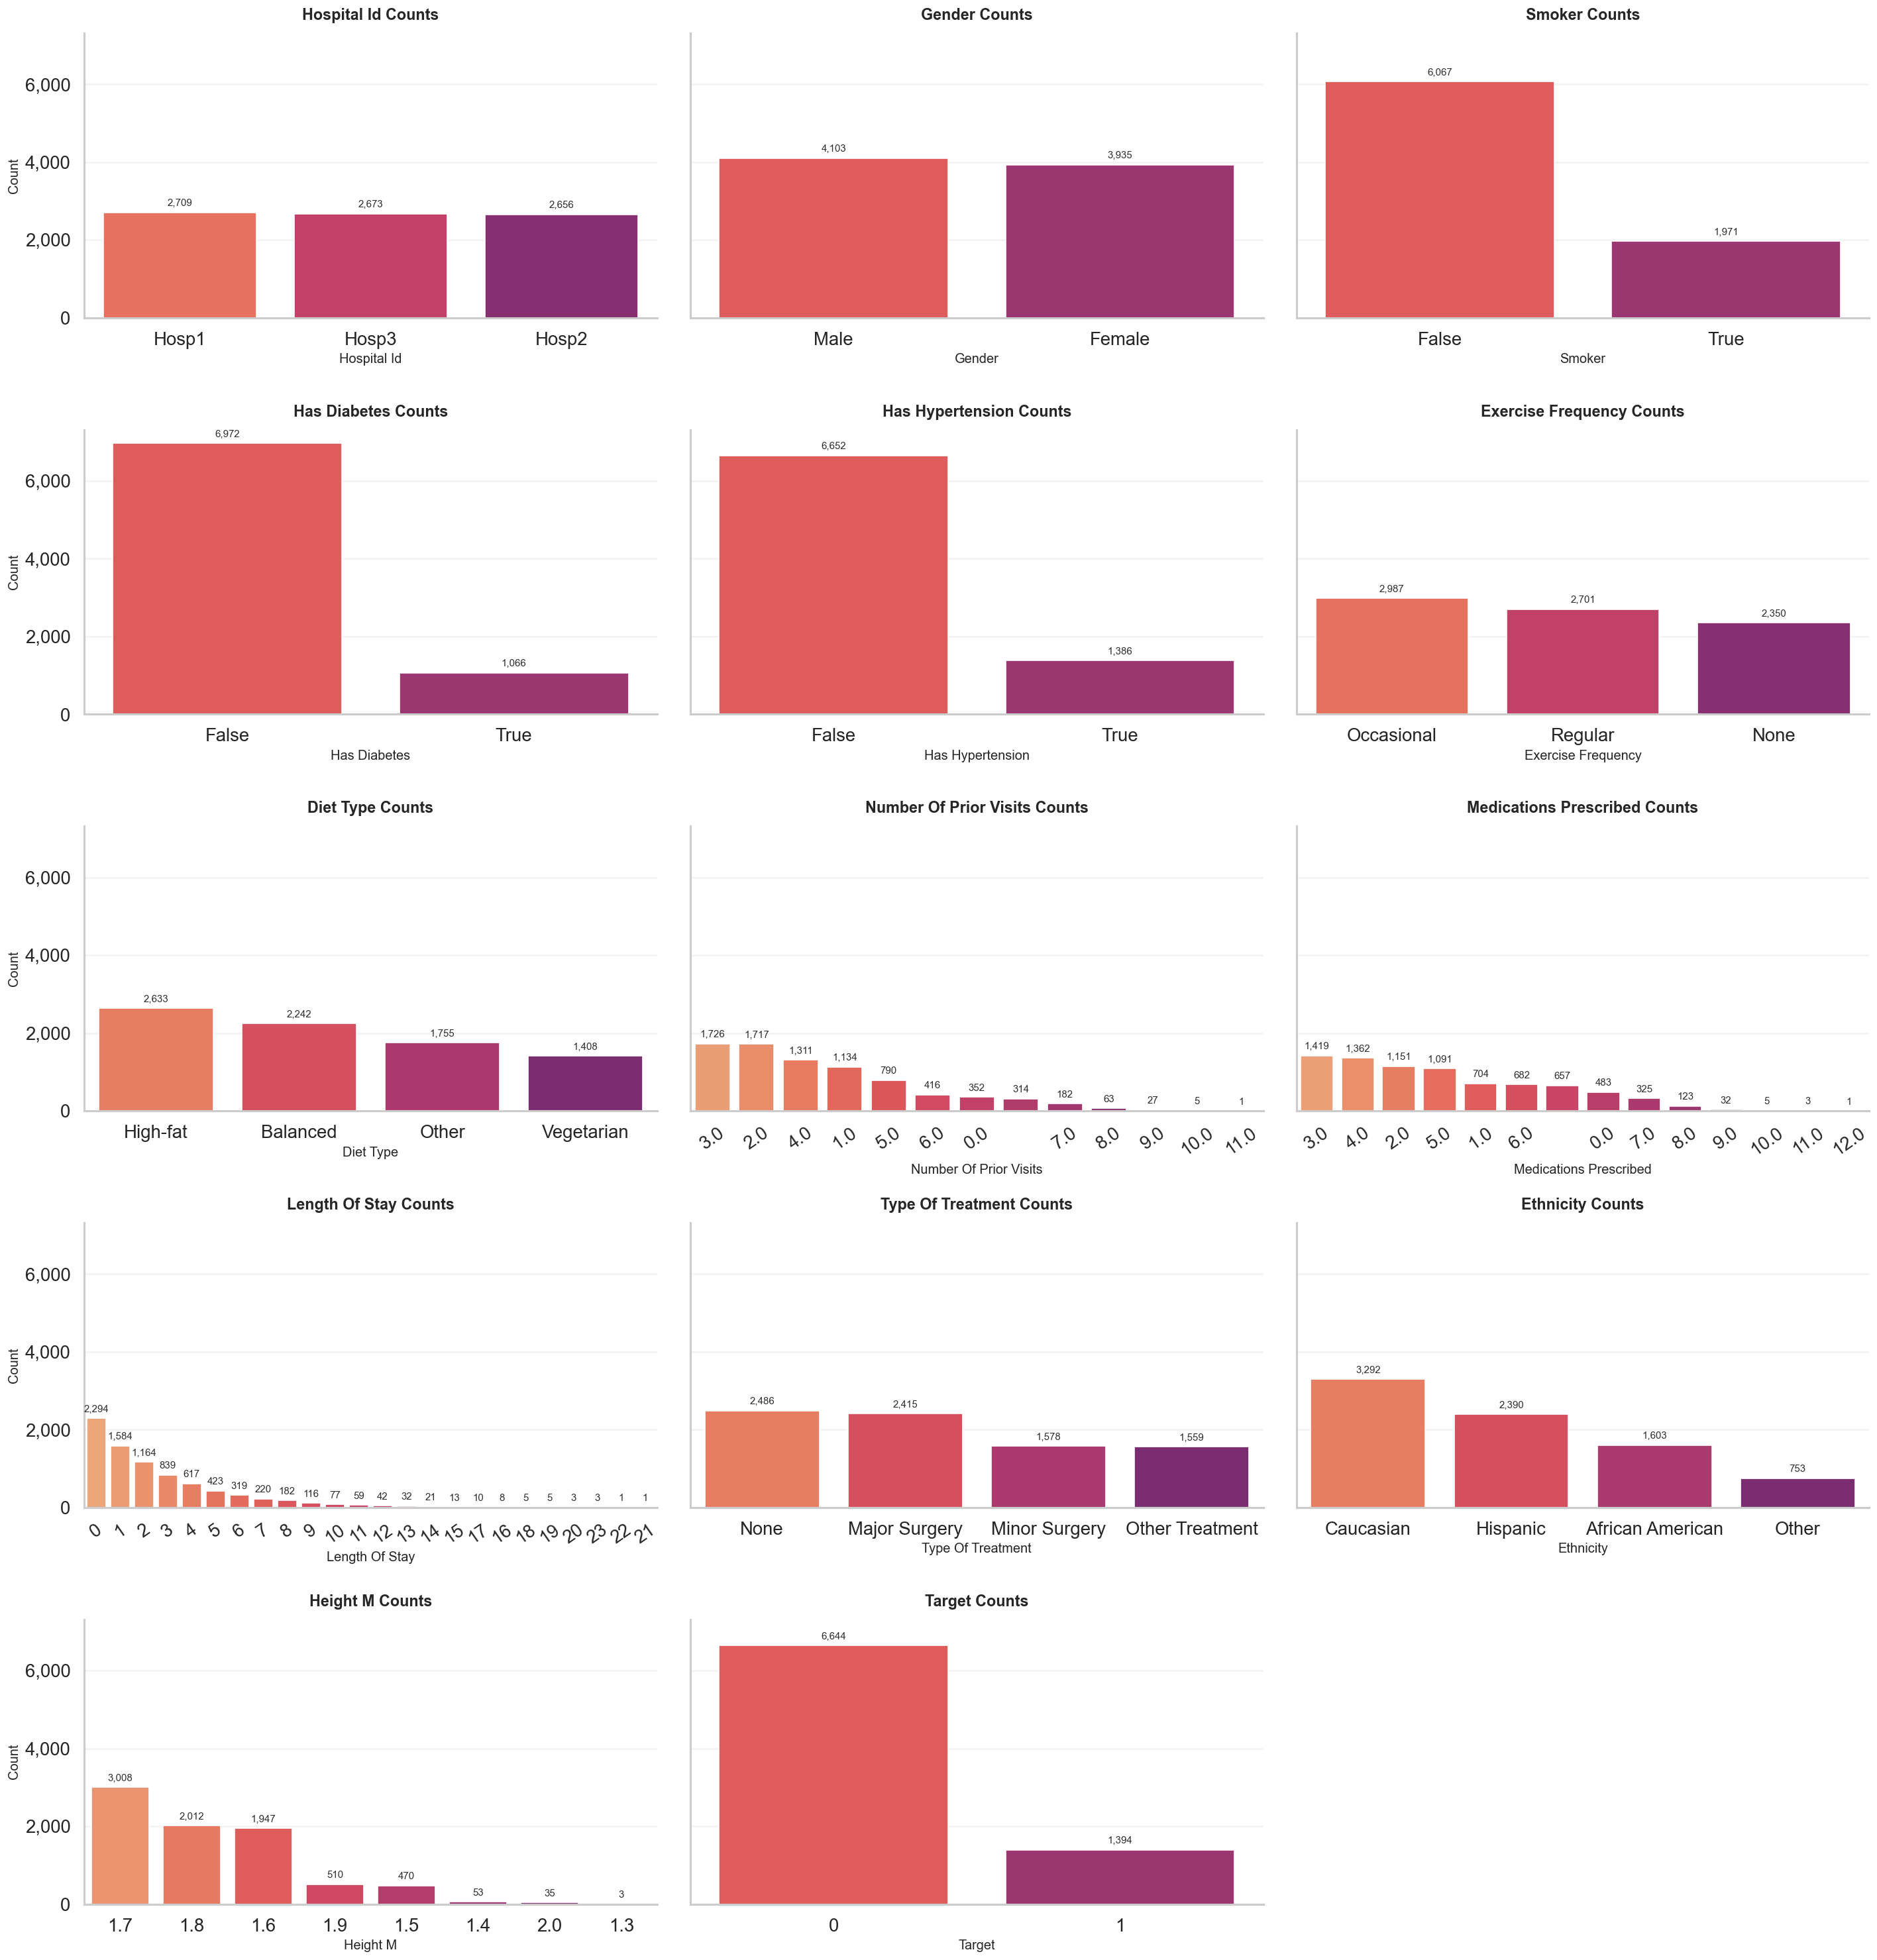

In [44]:
set_theme()

categories = [
    "hospital_id",
    "gender",
    "smoker",
    "has_diabetes",
    "has_hypertension",
    "exercise_frequency",
    "diet_type",
    "number_of_prior_visits",
    "medications_prescribed",
    "length_of_stay",
    "type_of_treatment",
    "ethnicity",
    "height_m",
    "target"
]

plot_grid(
    df=df,
    column_names=categories,
    plot_func=plot_barplot,
    palette="flare",
    n_plot_cols=3,
    sharey=True,
)

(<Figure size 1920x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Bmi Distribution'}, xlabel='Bmi', ylabel='Count'>,
        <Axes: title={'center': 'Weight Kg Distribution'}, xlabel='Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Adjusted Weight Kg Distribution'}, xlabel='Adjusted Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Count'>],
       dtype=object))

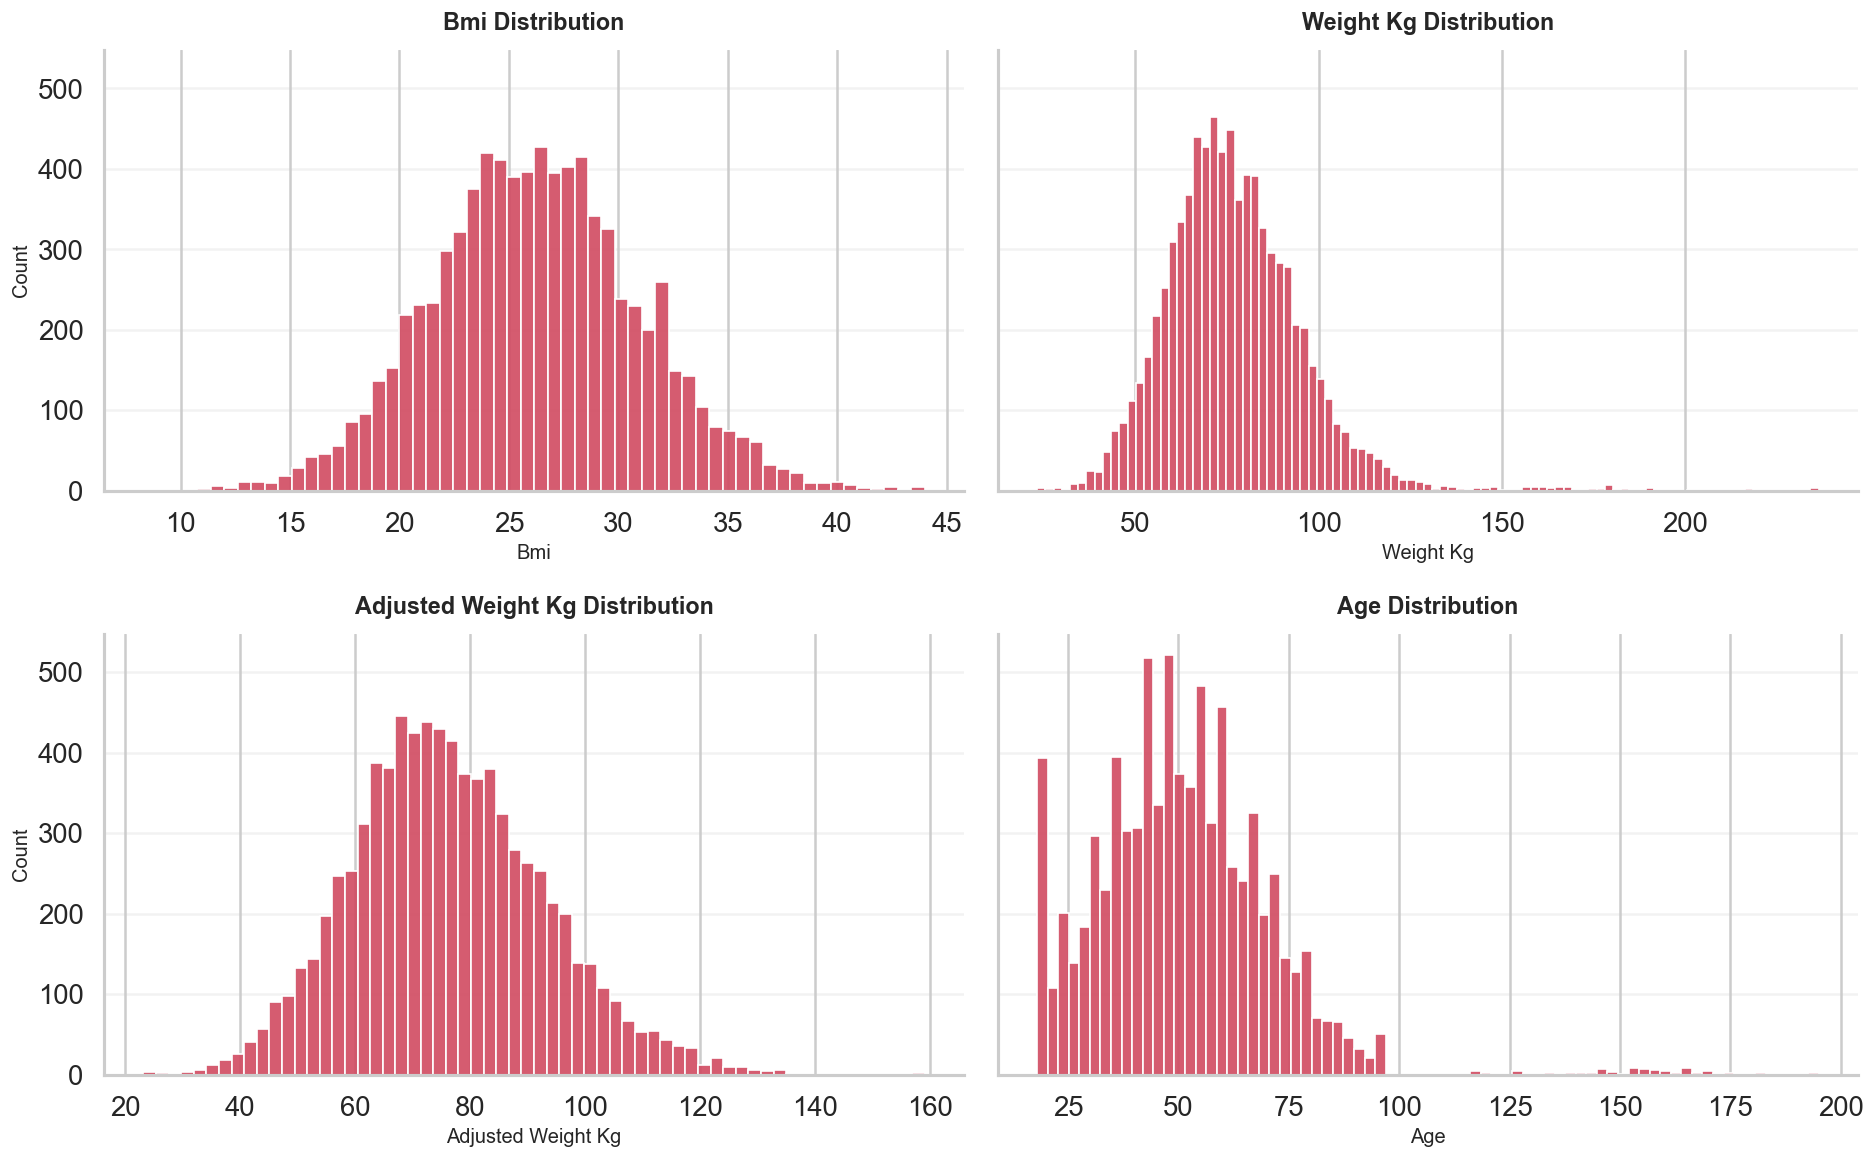

In [41]:
set_theme()

measure_cols = ["bmi", "weight_kg", "adjusted_weight_kg", "age"]

plot_grid(
    df=df,
    column_names=measure_cols,
    plot_func=plot_histogram,
    n_plot_cols=2,
    sharey=True, 
    bins="auto",
    stat="count",
    kde=False,
    show_bin_counts=False,
)

### **Initial Distribution Notes**
- age seems to have a large number of impossible outliers
- target is imbalanced
- other features have some potential outliers, but age will be handled first and then 
rechecked to see if they are of the same column

## **GCS CATCHUP**

In [46]:
PROJECT_ID = "readmission-543-project"
LOCATION = "us-central1"
BUCKET_ROOT_URI = "gs://readmission-bucket"


In [49]:
from google.cloud import aiplatform

aiplatform.init(project=PROJECT_ID, location=LOCATION )


In [ ]:
df_v0 = pd.read_csv('../data/interim/1.0-initial-cleaned-data.csv', keep_default_na=False)

In [119]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            digest.update(chunk)
    return digest.hexdigest()


def make_manifest(
    VERSION_ID: str,
    DATASET_GCS_URI: str,
    DATASET_LOCAL_PATH: Path,
    LOCAL_VERSION_DIR: Path,
    description: str = "",
    tags: list[str] | None = None,
):
    manifest = {
        "version_id": VERSION_ID,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "dataset_uri": DATASET_GCS_URI,
        "source_file": str(DATASET_LOCAL_PATH.resolve()),
        "sha256": sha256_file(DATASET_LOCAL_PATH),
        "row_count": int(df_v0.shape[0]),
        "column_count": int(df_v0.shape[1]),
        "columns": [str(c) for c in df_v0.columns.tolist()],
        "label_column": "target",
        "description": description,
        "tags": tags or [],
    }

    manifest_path = LOCAL_VERSION_DIR / "manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
    return manifest_path, manifest

In [120]:
from google.cloud import storage
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import re


def log_dataset_to_gcs(
    DATASET_LOCAL_PATH: Path,
    VERSION_ID: str,
    BUCKET_ROOT_URI: str,
    LOCAL_VERSION_DIR: Path,
    PROJECT_ID: str,
    log_experiment: bool,
    EXPERIMENT_NAME: str,
    description: str = "",
    tags: list[str] | None = None,
    resume_run: bool = False,
):
    """
    Log a dataset version to GCS and optionally record metadata in Vertex Experiments.

    Args:
        description: Human-readable summary of what changed in this version.
        tags:        List of labels e.g. ["cleaned", "outliers-removed", "v0"].
        resume_run:  If True, resume an existing run with the same name.
    """
    DATASET_GCS_URI = f"{BUCKET_ROOT_URI}/datasets/readmissions/{VERSION_ID}/train.csv"
    LOCAL_VERSION_DIR = Path("../data/versions") / VERSION_ID
    LOCAL_VERSION_DIR.mkdir(parents=True, exist_ok=True)

    manifest_path, manifest = make_manifest(
        VERSION_ID, DATASET_GCS_URI, DATASET_LOCAL_PATH, LOCAL_VERSION_DIR,
        description=description, tags=tags,
    )

    client = storage.Client(project=PROJECT_ID)
    bucket_name = BUCKET_ROOT_URI.replace("gs://", "").split("/")[0]
    bucket = client.bucket(bucket_name)

    dataset_blob_path = f"datasets/readmissions/{VERSION_ID}/train.csv"
    manifest_blob_path = f"datasets/readmissions/{VERSION_ID}/manifest.json"

    bucket.blob(dataset_blob_path).upload_from_filename(str(DATASET_LOCAL_PATH))
    bucket.blob(manifest_blob_path).upload_from_filename(str(manifest_path))

    print(f"Uploaded: gs://{bucket_name}/{dataset_blob_path}")
    print(f"Uploaded: gs://{bucket_name}/{manifest_blob_path}")

    if log_experiment:
        raw_run_name = f"readmissions-data-{VERSION_ID}"
        RUN_NAME = re.sub(r"[^a-z0-9-]+", "-", raw_run_name.lower()).strip("-")[:120]

        aiplatform.init(
            project=PROJECT_ID, location=LOCATION, experiment=EXPERIMENT_NAME
        )
        aiplatform.start_run(run=RUN_NAME, resume=resume_run)
        aiplatform.log_params(
            {
                "dataset_version": VERSION_ID,
                "dataset_uri": DATASET_GCS_URI,
                "manifest_uri": f"{BUCKET_ROOT_URI}/datasets/readmissions/{VERSION_ID}/manifest.json",
                "row_count": manifest["row_count"],
                "column_count": manifest["column_count"],
                "description": description,
                "tags": ",".join(tags or []),
            }
        )
        aiplatform.end_run()
        print(
            f"Logged dataset version to Vertex Experiments: {EXPERIMENT_NAME} / {RUN_NAME}"
        )

In [ ]:
log_dataset_to_gcs(
    DATASET_LOCAL_PATH=Path("../data/interim/1.0-initial-cleaned-data.csv"),
    VERSION_ID="v0",
    BUCKET_ROOT_URI=BUCKET_ROOT_URI,
    LOCAL_VERSION_DIR=Path("../data/versions/v0"),
    PROJECT_ID=PROJECT_ID,
    log_experiment=True,
    EXPERIMENT_NAME="readmissions-data-versions",
    description="Initial cleaned dataset: no rows removed, just columns renamed and formatted",
    tags=["initial-clean", "v0"],
    resume_run=True,
)

Uploaded: gs://readmission-bucket/datasets/readmissions/v0/train.csv
Uploaded: gs://readmission-bucket/datasets/readmissions/v0/manifest.json


Logged dataset version to Vertex Experiments: readmissions-data-versions / readmissions-data-v0


## **OUTLIER CHECKING AGAIN** 

In [93]:
# age outlier checking

age_z_scores = np.abs(stats.zscore(df["age"]))
age_outliers = np.where(age_z_scores > threshold)[0]
print(f"Identified {len(age_outliers)} age outliers at threshold {threshold}: {age_outliers}")

display(df.loc[age_outliers, "age"])

Identified 80 age outliers at threshold 3: [ 122  136  253  535  547  593  653  871 1085 1135 1137 1320 1389 1475
 1527 1876 1902 1962 2258 2407 2442 2444 2504 2701 2733 2812 2854 2865
 2891 2906 2990 3045 3061 3148 3229 3506 3518 3670 3772 3983 4070 4238
 4258 4326 4551 4553 4617 4663 4740 4902 5047 5121 5205 5210 5232 5278
 5487 5603 5639 5664 5802 6028 6062 6146 6275 6341 6450 6525 6532 6668
 6875 6903 6908 6953 7216 7251 7589 7814 7976 8027]


122     158
136     167
253     126
535     147
547     120
       ... 
7251    136
7589    165
7814    195
7976    145
8027    156
Name: age, Length: 80, dtype: int64

## discussion
all of the age outliers make sense (as outliers that is) so i will be removing their rows : ) 

In [ ]:
df_edit = df.copy()

df_edit = df_edit.drop(index=age_outliers).reset_index(drop=True)

In [107]:
cols = ["medications_prescribed", "number_of_prior_visits"]

# Replace truly empty strings or whitespace-only cells with null
df_edit[cols] = df_edit[cols].replace(r"^\s*$", pd.NA, regex=True)

# Optional: make number_of_prior_visits numeric (invalid/empty -> null)
df_edit["number_of_prior_visits"] = pd.to_numeric(
    df_edit["number_of_prior_visits"], errors="coerce"
)

In [108]:
display(df_edit.shape)

display(df_edit.head())


(7958, 19)

,patient_id,age,gender,ethnicity,hospital_id,height_m,smoker,bmi,weight_kg,adjusted_weight_kg,has_diabetes,has_hypertension,exercise_frequency,diet_type,number_of_prior_visits,medications_prescribed,length_of_stay,type_of_treatment,target
0,1000000,23,Female,African American,Hosp2,1.6,False,25.0,64.0,63.283346,False,False,Regular,High-fat,3.0,3.0,0,None,0
1,1000002,56,Female,Hispanic,Hosp3,1.8,True,27.0,87.5,87.678859,False,False,Regular,High-fat,2.0,NaN,2,None,0
2,1000003,28,Male,African American,Hosp1,1.8,False,35.0,113.4,113.497844,False,True,None,Other,NaN,2.0,5,None,0
3,1000004,70,Female,Caucasian,Hosp2,1.8,False,27.7,89.7,89.717694,False,False,None,Other,3.0,NaN,0,Major Surgery,0
4,1000005,48,Female,Hispanic,Hosp1,1.9,False,22.4,80.9,80.528927,False,False,Occasional,High-fat,7.0,5.0,7,Major Surgery,1


In [110]:
display(df_edit.info())

<class 'pandas.DataFrame'>
RangeIndex: 7958 entries, 0 to 7957
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   patient_id              7958 non-null   int64  
 1   age                     7958 non-null   int64  
 2   gender                  7958 non-null   str    
 3   ethnicity               7958 non-null   str    
 4   hospital_id             7958 non-null   str    
 5   height_m                7958 non-null   float64
 6   smoker                  7958 non-null   bool   
 7   bmi                     7958 non-null   float64
 8   weight_kg               7958 non-null   float64
 9   adjusted_weight_kg      7958 non-null   float64
 10  has_diabetes            7958 non-null   bool   
 11  has_hypertension        7958 non-null   bool   
 12  exercise_frequency      7958 non-null   str    
 13  diet_type               7958 non-null   str    
 14  number_of_prior_visits  7646 non-null   float64
 15

None

In [111]:
# outlier checking again - age is chill

def modified_z_score(data):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    return 0.6745 * (data - median) / mad

mod_z = np.abs(modified_z_score(np.array(df_edit["age"])))
outliers = np.where(mod_z > 3.5)

outliers_df = df_edit.iloc[outliers]

outliers_df[["age"]]

,age


In [125]:
mod_z = np.abs(modified_z_score(np.array(df_edit["bmi"])))
outliers = np.where(mod_z > 3.5)

outliers_df = df_edit.iloc[outliers]

outliers_df
bmi_outliers_idx = outliers_df.index.tolist()
print(f"Identified {len(bmi_outliers_idx)} BMI outliers at modified z-score threshold 3.5: {bmi_outliers_idx}")


Identified 10 BMI outliers at modified z-score threshold 3.5: [792, 797, 1547, 3386, 3878, 4444, 4771, 4820, 5457, 6398]


the bmi outliers are all pretty insane although technically possible (as in like severe anorexia or morbidly obese range).
I think i am going to delete them since they are extrmeely extreme and the diet type and excercise frequency features
dont seem to align.
actually going to make two different dataset versions, one with age outliers removed and one with these removed two

In [ ]:
df_edit.to_csv("../data/interim/1.1-edited-data.csv", index=False)


In [121]:
log_dataset_to_gcs(
    DATASET_LOCAL_PATH=Path("../data/interim/1.1-edited-data.csv"),
    VERSION_ID="v1.0",
    BUCKET_ROOT_URI=BUCKET_ROOT_URI,
    LOCAL_VERSION_DIR=Path("../data/versions/v0"),
    PROJECT_ID=PROJECT_ID,
    log_experiment=True,
    EXPERIMENT_NAME="readmissions-data-versions",
    description="cleaned dataset foundation with z-score age outliers removed, bmi outliers still included",
    tags=["eda-1.0", "v1.0", "age-outliers-removed"],
    resume_run=False,
 )

Uploaded: gs://readmission-bucket/datasets/readmissions/v1.0/train.csv
Uploaded: gs://readmission-bucket/datasets/readmissions/v1.0/manifest.json


Associating projects/182027088454/locations/us-central1/metadataStores/default/contexts/readmissions-data-versions-readmissions-data-v1-0 to Experiment: readmissions-data-versions


Logged dataset version to Vertex Experiments: readmissions-data-versions / readmissions-data-v1-0


In [126]:
df_edit2 = df_edit.copy()

df_edit2 = df_edit2.drop(index=bmi_outliers_idx).reset_index(drop=True)

In [127]:
df_edit2.to_csv("../data/interim/1.2-edited-data.csv", index=False)

In [128]:
log_dataset_to_gcs(
    DATASET_LOCAL_PATH=Path("../data/interim/1.2-edited-data.csv"),
    VERSION_ID="v1.2",
    BUCKET_ROOT_URI=BUCKET_ROOT_URI,
    LOCAL_VERSION_DIR=Path("../data/versions/v0"),
    PROJECT_ID=PROJECT_ID,
    log_experiment=True,
    EXPERIMENT_NAME="readmissions-data-versions",
    description="cleaned dataset foundation with z-score age outliers removed, bmi outliers also  removed",
    tags=["eda-1.0", "v1.2", "age-outliers-removed", "bmi-outliers-removed"],
    resume_run=False,
 )

Uploaded: gs://readmission-bucket/datasets/readmissions/v1.2/train.csv
Uploaded: gs://readmission-bucket/datasets/readmissions/v1.2/manifest.json


Associating projects/182027088454/locations/us-central1/metadataStores/default/contexts/readmissions-data-versions-readmissions-data-v1-2 to Experiment: readmissions-data-versions


Logged dataset version to Vertex Experiments: readmissions-data-versions / readmissions-data-v1-2


#rerun distributions on 1.2 data

(<Figure size 1920x1200 with 4 Axes>,
 array([<Axes: title={'center': 'Bmi Distribution'}, xlabel='Bmi', ylabel='Count'>,
        <Axes: title={'center': 'Weight Kg Distribution'}, xlabel='Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Adjusted Weight Kg Distribution'}, xlabel='Adjusted Weight Kg', ylabel='Count'>,
        <Axes: title={'center': 'Age Distribution'}, xlabel='Age', ylabel='Count'>],
       dtype=object))

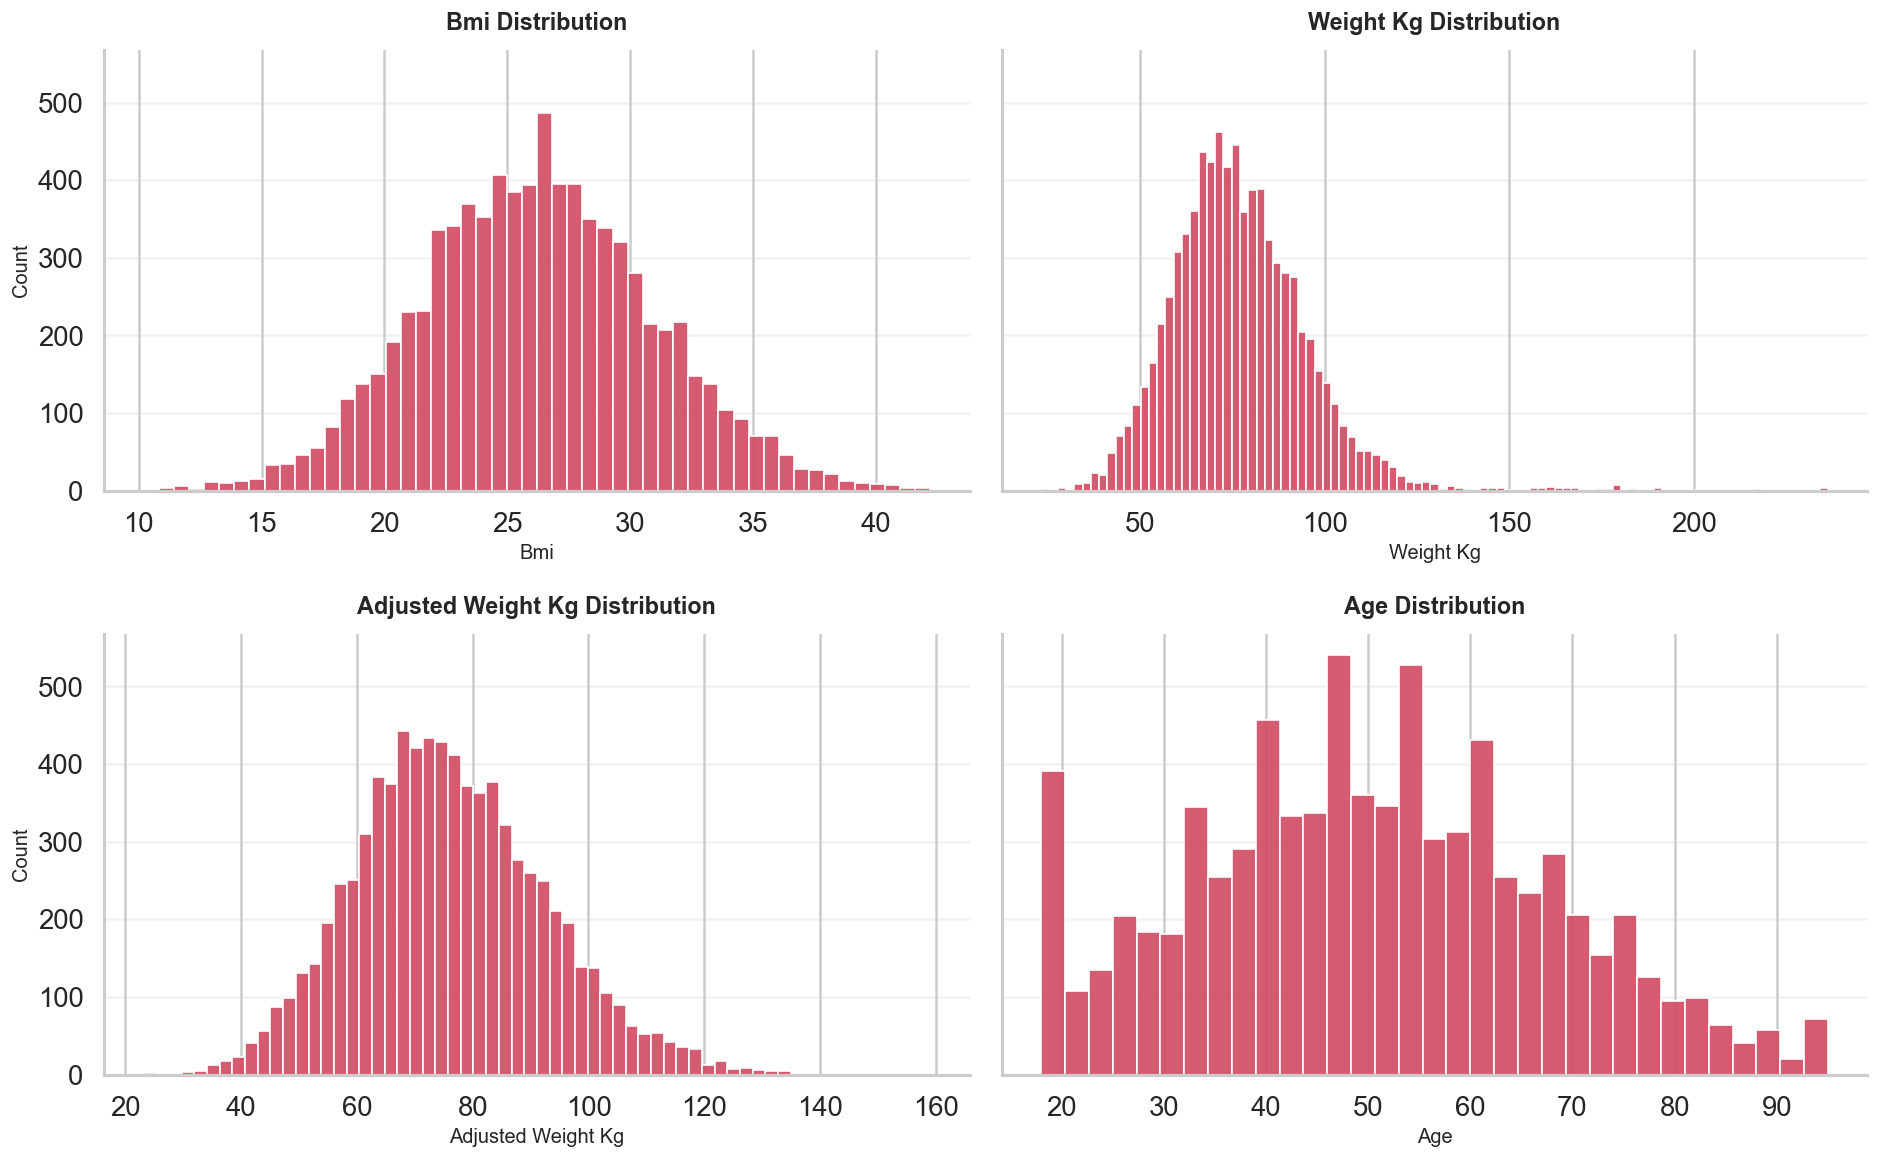

In [129]:
plot_grid(
    df=df_edit2,
    column_names=measure_cols,
    plot_func=plot_histogram,
    n_plot_cols=2,
    sharey=True, 
    bins="auto",
    stat="count",
    kde=False,
    show_bin_counts=False,
)

(<Figure size 2880x3000 with 14 Axes>,
 array([<Axes: title={'center': 'Hospital Id Counts'}, xlabel='Hospital Id', ylabel='Count'>,
        <Axes: title={'center': 'Gender Counts'}, xlabel='Gender', ylabel='Count'>,
        <Axes: title={'center': 'Smoker Counts'}, xlabel='Smoker', ylabel='Count'>,
        <Axes: title={'center': 'Has Diabetes Counts'}, xlabel='Has Diabetes', ylabel='Count'>,
        <Axes: title={'center': 'Has Hypertension Counts'}, xlabel='Has Hypertension', ylabel='Count'>,
        <Axes: title={'center': 'Exercise Frequency Counts'}, xlabel='Exercise Frequency', ylabel='Count'>,
        <Axes: title={'center': 'Diet Type Counts'}, xlabel='Diet Type', ylabel='Count'>,
        <Axes: title={'center': 'Number Of Prior Visits Counts'}, xlabel='Number Of Prior Visits', ylabel='Count'>,
        <Axes: title={'center': 'Medications Prescribed Counts'}, xlabel='Medications Prescribed', ylabel='Count'>,
        <Axes: title={'center': 'Length Of Stay Counts'}, xlabel='Len

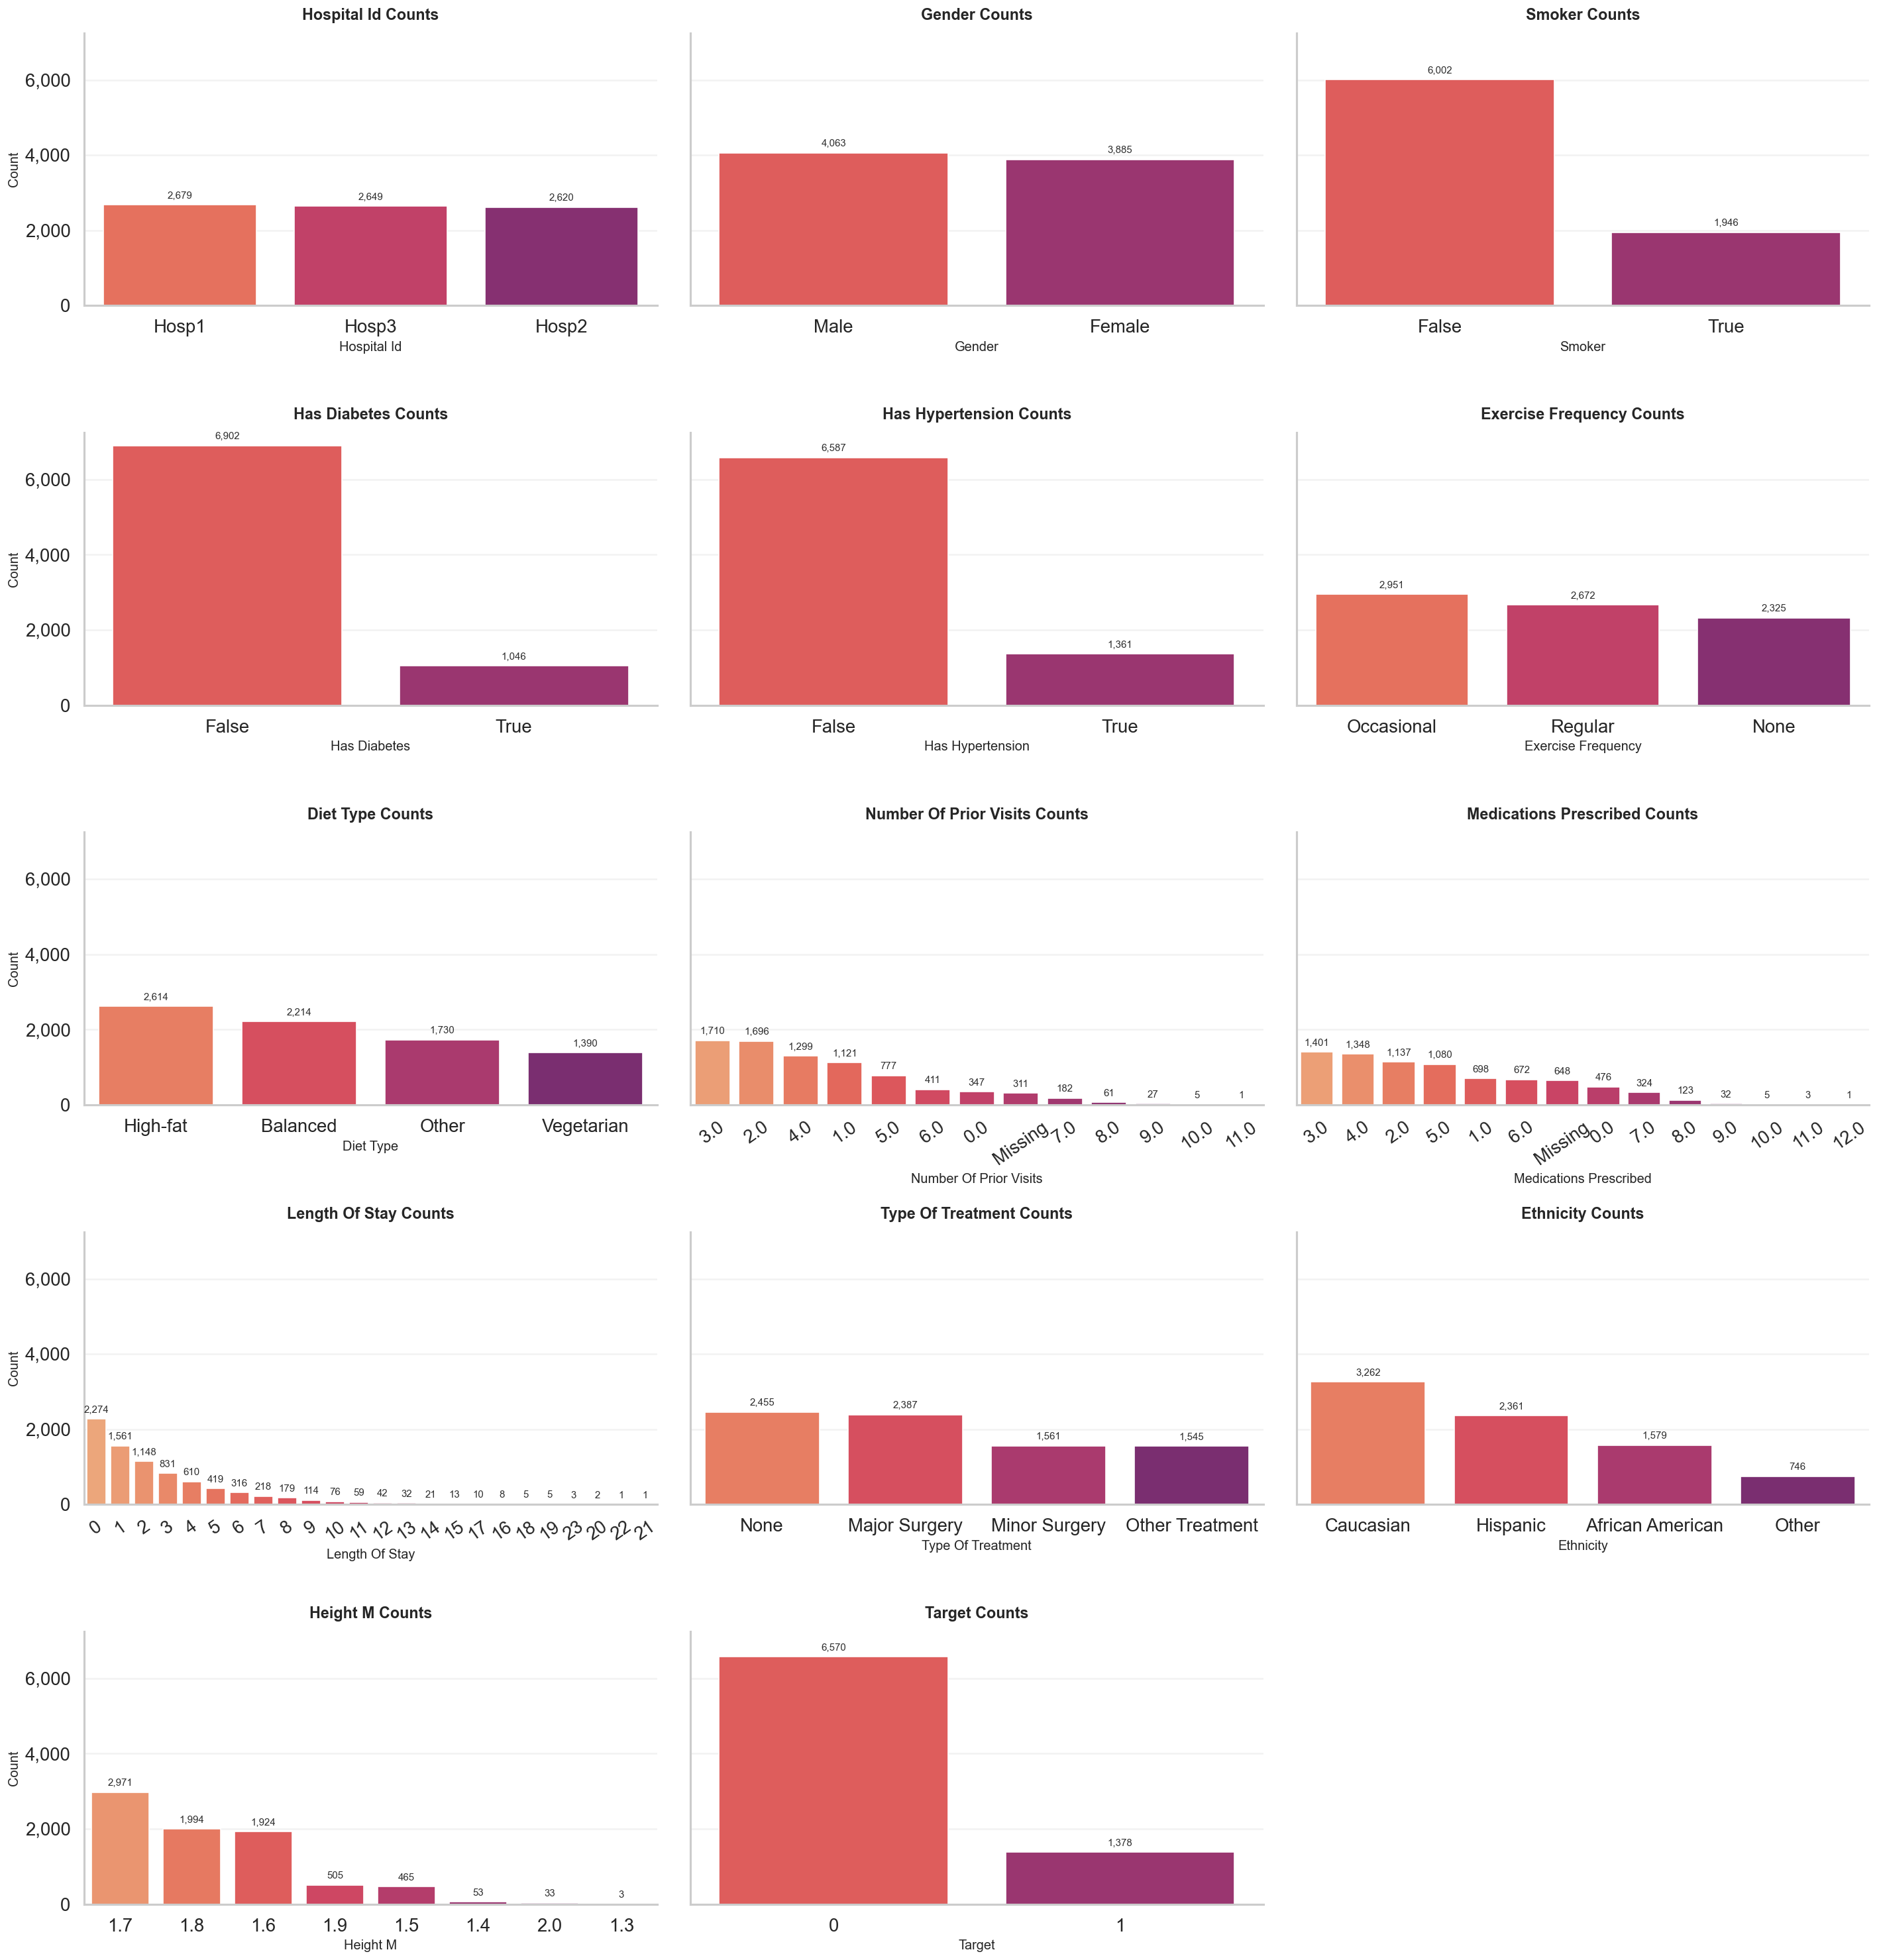

In [131]:
plot_grid(
    df=df_edit2,
    column_names=categories,
    plot_func=plot_barplot,
    palette="flare",
    n_plot_cols=3,
    sharey=True,
)

## **Bivariate Analysis**

In [185]:
def plot_numeric_x_numeric_grid(
    df,
    base_numeric_col,
    numeric_cols,
    plot_func='hexbin',
    n_plot_cols=2,
    figsize_scale=(8, 5),
    **plot_kwargs,
):
    """
    Generic grid renderer for plotting a base numeric column against multiple other numeric columns.
    
    Args:
        df: DataFrame
        base_numeric_col: The numeric column to compare against (e.g., "bmi")
        numeric_cols: List of numeric columns to plot against the base (e.g., ["age", "weight_kg", "length_of_stay"])
        plot_func: 'hexbin' (default), 'scatter', or custom plotting function
        n_plot_cols: Number of columns in the grid
        figsize_scale: Tuple to scale figure size (width per plot, height per plot)
        **plot_kwargs: Additional keyword arguments to pass to the plotting function
                      For hexbin: gridsize, cmap, etc.
                      For scatter: alpha, color, size, etc.
    """
    n_plots = len(numeric_cols)
    n_rows = (n_plots - 1) // n_plot_cols + 1

    fig, axes = plt.subplots(
        n_rows,
        n_plot_cols,
        figsize=(figsize_scale[0] * n_plot_cols, figsize_scale[1] * n_rows),
    )

    axes = np.array(axes).reshape(-1)

    for i, x_col in enumerate(numeric_cols):
        if plot_func == 'hexbin':
            axes[i].hexbin(df[x_col], df[base_numeric_col], **plot_kwargs)
            axes[i].set_xlabel(x_col)
            axes[i].set_ylabel(base_numeric_col)
        elif plot_func == 'scatter':
            sns.scatterplot(data=df, x=x_col, y=base_numeric_col, ax=axes[i], **plot_kwargs)
        else:
            # Custom function - assume it accepts data, x, y, ax params
            plot_func(data=df, x=x_col, y=base_numeric_col, ax=axes[i], **plot_kwargs)
        
        axes[i].set_title(f"{x_col} vs {base_numeric_col}")

    # Remove empty subplots
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig, axes[:n_plots]


In [173]:
def plot_numeric_x_across_categories_grid(
    df,
    numeric_col,
    category_cols,
    plot_func=sns.boxplot,
    n_plot_cols=2,
    sharex=False,
    sharey=False,
    figsize_scale=(8, 5),
    **plot_kwargs,
):
    """
    Generic grid renderer for plotting a single numeric column across multiple categorical columns.
    
    Args:
        df: DataFrame
        numeric_col: The numeric column to plot (e.g., "bmi")
        category_cols: List of categorical columns to plot against
        plot_func: The plotting function to use (e.g., sns.boxplot, sns.violinplot)
        n_plot_cols: Number of columns in the grid
        sharex, sharey: Whether to share axes
        figsize_scale: Tuple to scale figure size (width per plot, height per plot)
        **plot_kwargs: Additional keyword arguments to pass to the plotting function
    """
    n_plots = len(category_cols)
    n_rows = (n_plots - 1) // n_plot_cols + 1

    fig, axes = plt.subplots(
        n_rows,
        n_plot_cols,
        figsize=(figsize_scale[0] * n_plot_cols, figsize_scale[1] * n_rows),
        sharex=sharex,
        sharey=sharey,
    )

    axes = np.array(axes).reshape(-1)

    for i, cat_col in enumerate(category_cols):
        plot_func(
            data=df,
            x=cat_col,
            y=numeric_col,
            ax=axes[i],
            **plot_kwargs,
        )
        axes[i].set_title(f"{numeric_col} by {cat_col}")

    # Remove empty subplots
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig, axes[:n_plots]


(<Figure size 2160x1440 with 7 Axes>,
 array([<Axes: title={'center': 'age by target'}, xlabel='target', ylabel='age'>,
        <Axes: title={'center': 'height_m by target'}, xlabel='target', ylabel='height_m'>,
        <Axes: title={'center': 'bmi by target'}, xlabel='target', ylabel='bmi'>,
        <Axes: title={'center': 'weight_kg by target'}, xlabel='target', ylabel='weight_kg'>,
        <Axes: title={'center': 'adjusted_weight_kg by target'}, xlabel='target', ylabel='adjusted_weight_kg'>,
        <Axes: title={'center': 'number_of_prior_visits by target'}, xlabel='target', ylabel='number_of_prior_visits'>,
        <Axes: title={'center': 'length_of_stay by target'}, xlabel='target', ylabel='length_of_stay'>],
       dtype=object))

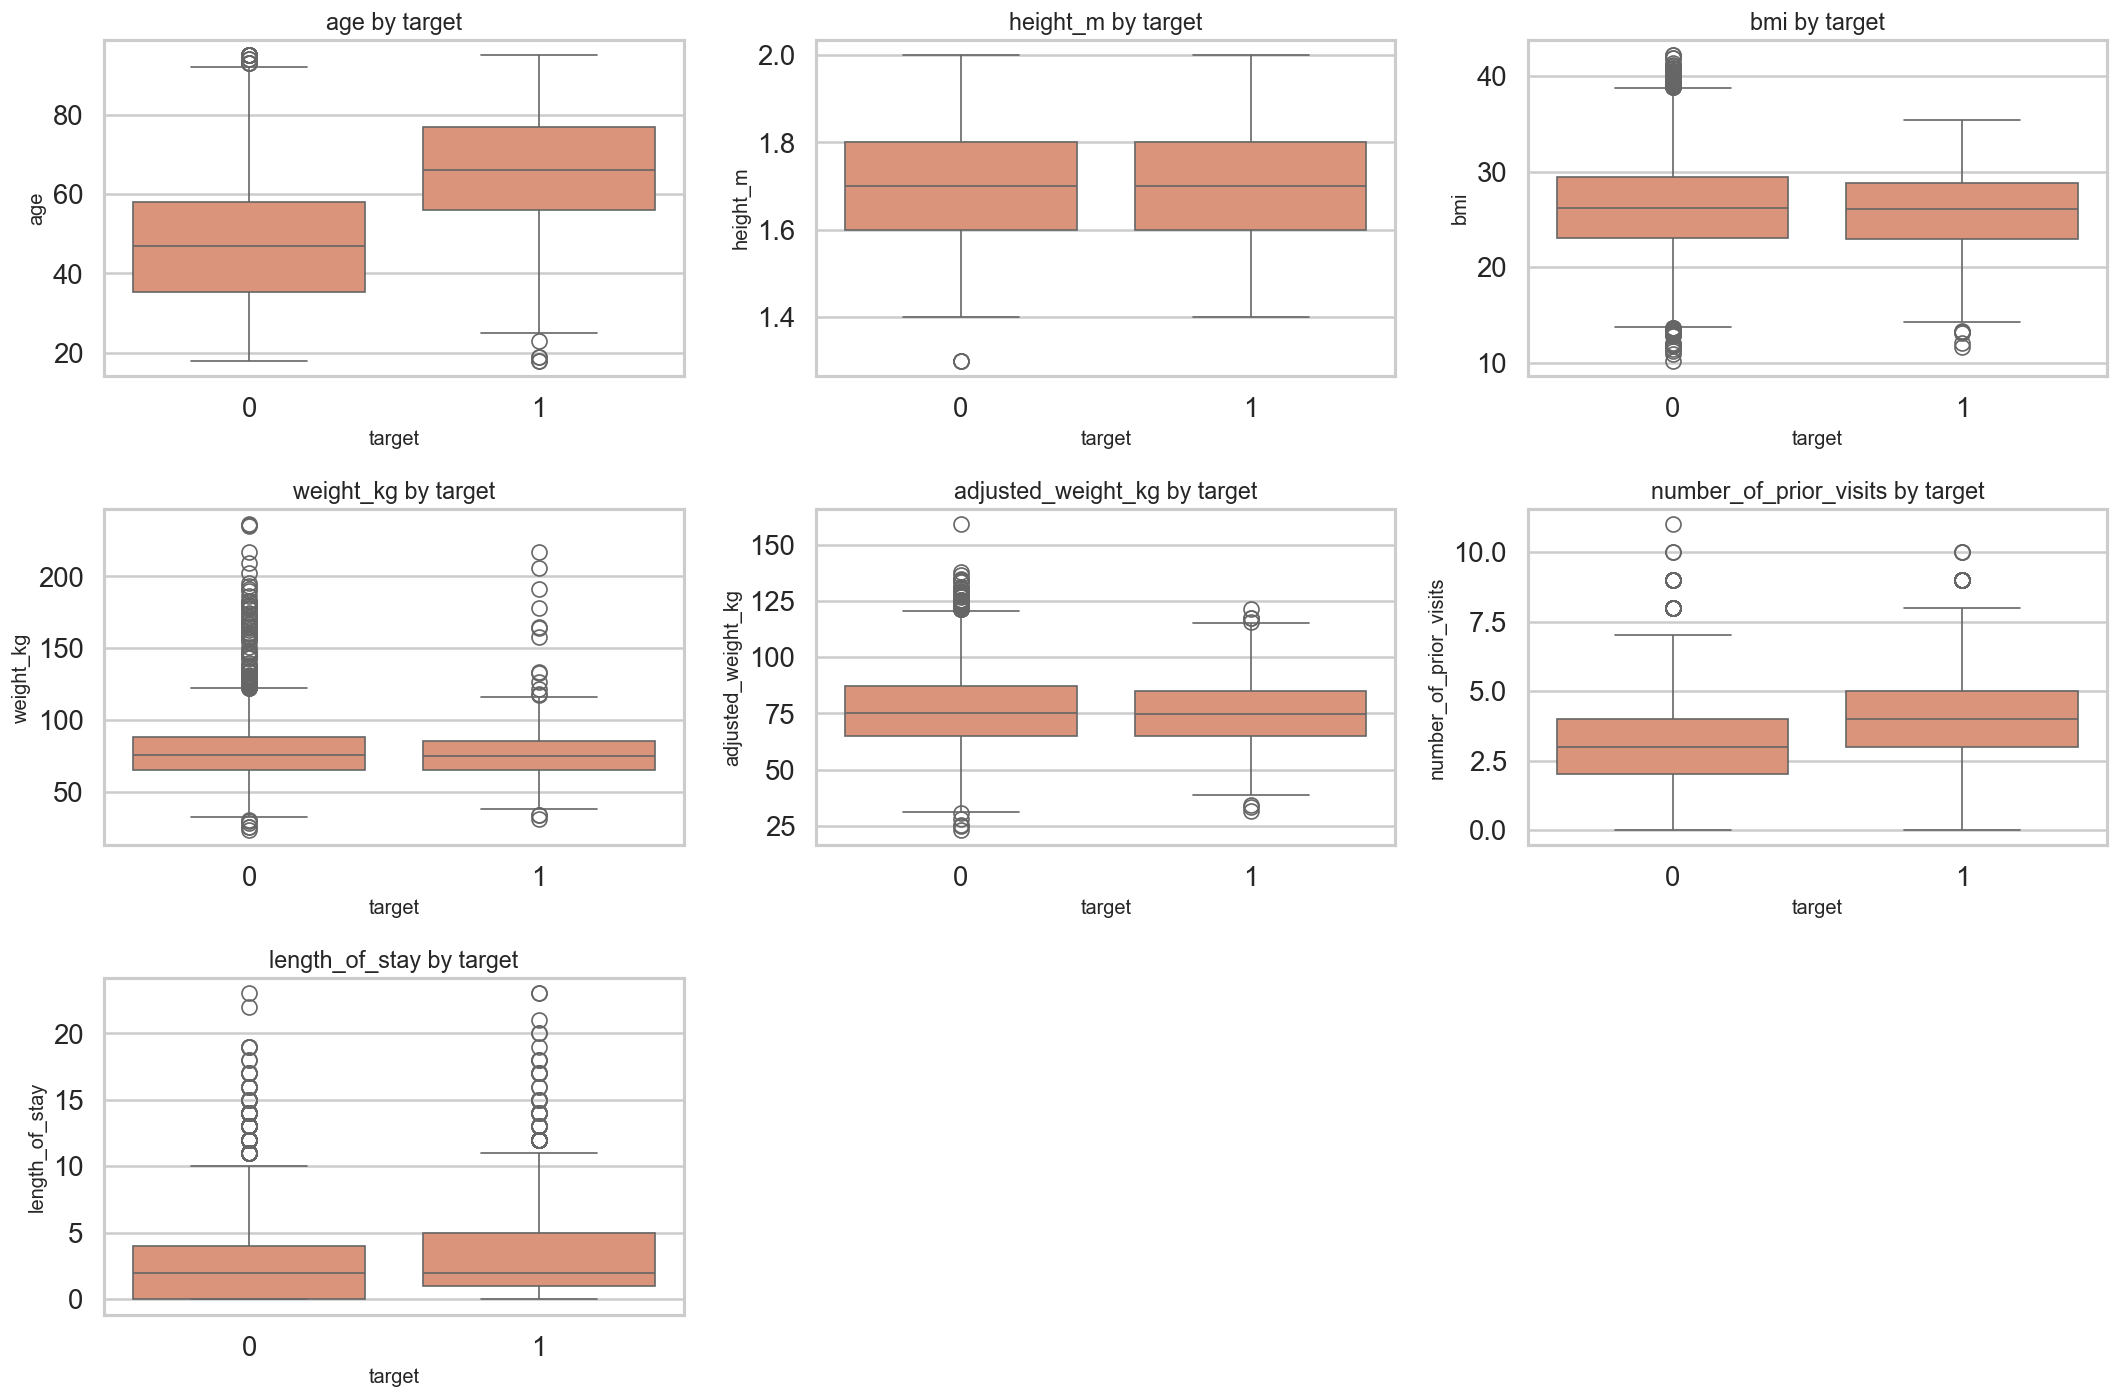

In [192]:
def plot_all_numeric_by_base_category_grid(
    df,
    base_cat_col="target",
    numeric_cols=None,
    plot_func=sns.boxplot,
    n_plot_cols=3,
    figsize_scale=(6, 4),
    exclude_id_like=True,
    **plot_kwargs,
):
    """
    Plot all numeric columns split by one base categorical column in a subplot grid.

    Args:
        df: DataFrame
        base_cat_col: Categorical column used on x-axis for every subplot
        numeric_cols: Optional list of numeric columns; if None, auto-detect numeric columns
        plot_func: Plot function (default sns.boxplot)
        n_plot_cols: Number of subplot columns
        figsize_scale: Width/height scale per subplot
        exclude_id_like: Exclude columns ending in '_id' during auto-detection
        **plot_kwargs: Extra args passed into plot_func
    """
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    numeric_cols = [c for c in numeric_cols if c != base_cat_col]

    if exclude_id_like:
        numeric_cols = [c for c in numeric_cols if not c.lower().endswith("_id")]

    if not numeric_cols:
        raise ValueError("No numeric columns available to plot.")

    n_plots = len(numeric_cols)
    n_rows = (n_plots - 1) // n_plot_cols + 1

    fig, axes = plt.subplots(
        n_rows,
        n_plot_cols,
        figsize=(figsize_scale[0] * n_plot_cols, figsize_scale[1] * n_rows),
    )
    axes = np.array(axes).reshape(-1)

    for i, num_col in enumerate(numeric_cols):
        plot_func(
            data=df,
            x=base_cat_col,
            y=num_col,
            ax=axes[i],
            **plot_kwargs,
        )
        axes[i].set_title(f"{num_col} by {base_cat_col}")

    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig, axes[:n_plots]


In [181]:
def plot_categorical_x_categorical_grid(
    df,
    base_cat_col,
    category_cols,
    plot_func=sns.countplot,
    n_plot_cols=2,
    sharex=False,
    sharey=False,
    figsize_scale=(8, 5),
    **plot_kwargs,
):
    """
    Generic grid renderer for plotting relationships between multiple categorical columns and a base column.
    
    Args:
        df: DataFrame
        base_cat_col: The base categorical column to use as hue for all plots (e.g., "target")
        category_cols: List of categorical columns to plot on x-axis (e.g., ["smoker", "has_diabetes", "exercise_frequency"])
        plot_func: The plotting function to use (e.g., sns.countplot)
        n_plot_cols: Number of columns in the grid
        sharex, sharey: Whether to share axes
        figsize_scale: Tuple to scale figure size (width per plot, height per plot)
        **plot_kwargs: Additional keyword arguments to pass to the plotting function
    """
    n_plots = len(category_cols)
    n_rows = (n_plots - 1) // n_plot_cols + 1

    fig, axes = plt.subplots(
        n_rows,
        n_plot_cols,
        figsize=(figsize_scale[0] * n_plot_cols, figsize_scale[1] * n_rows),
        sharex=sharex,
        sharey=sharey,
    )

    axes = np.array(axes).reshape(-1)

    for i, cat_col_x in enumerate(category_cols):
        plot_func(
            data=df,
            x=cat_col_x,
            hue=base_cat_col,
            ax=axes[i],
            **plot_kwargs,
        )
        axes[i].set_title(f"{cat_col_x} by {base_cat_col}")

    # Remove empty subplots
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()
    return fig, axes[:n_plots]


(<Figure size 1920x1800 with 6 Axes>,
 array([<Axes: title={'center': 'smoker by target'}, xlabel='smoker', ylabel='count'>,
        <Axes: title={'center': 'has_diabetes by target'}, xlabel='has_diabetes', ylabel='count'>,
        <Axes: title={'center': 'exercise_frequency by target'}, xlabel='exercise_frequency', ylabel='count'>,
        <Axes: title={'center': 'diet_type by target'}, xlabel='diet_type', ylabel='count'>,
        <Axes: title={'center': 'gender by target'}, xlabel='gender', ylabel='count'>,
        <Axes: title={'center': 'has_hypertension by target'}, xlabel='has_hypertension', ylabel='count'>],
       dtype=object))

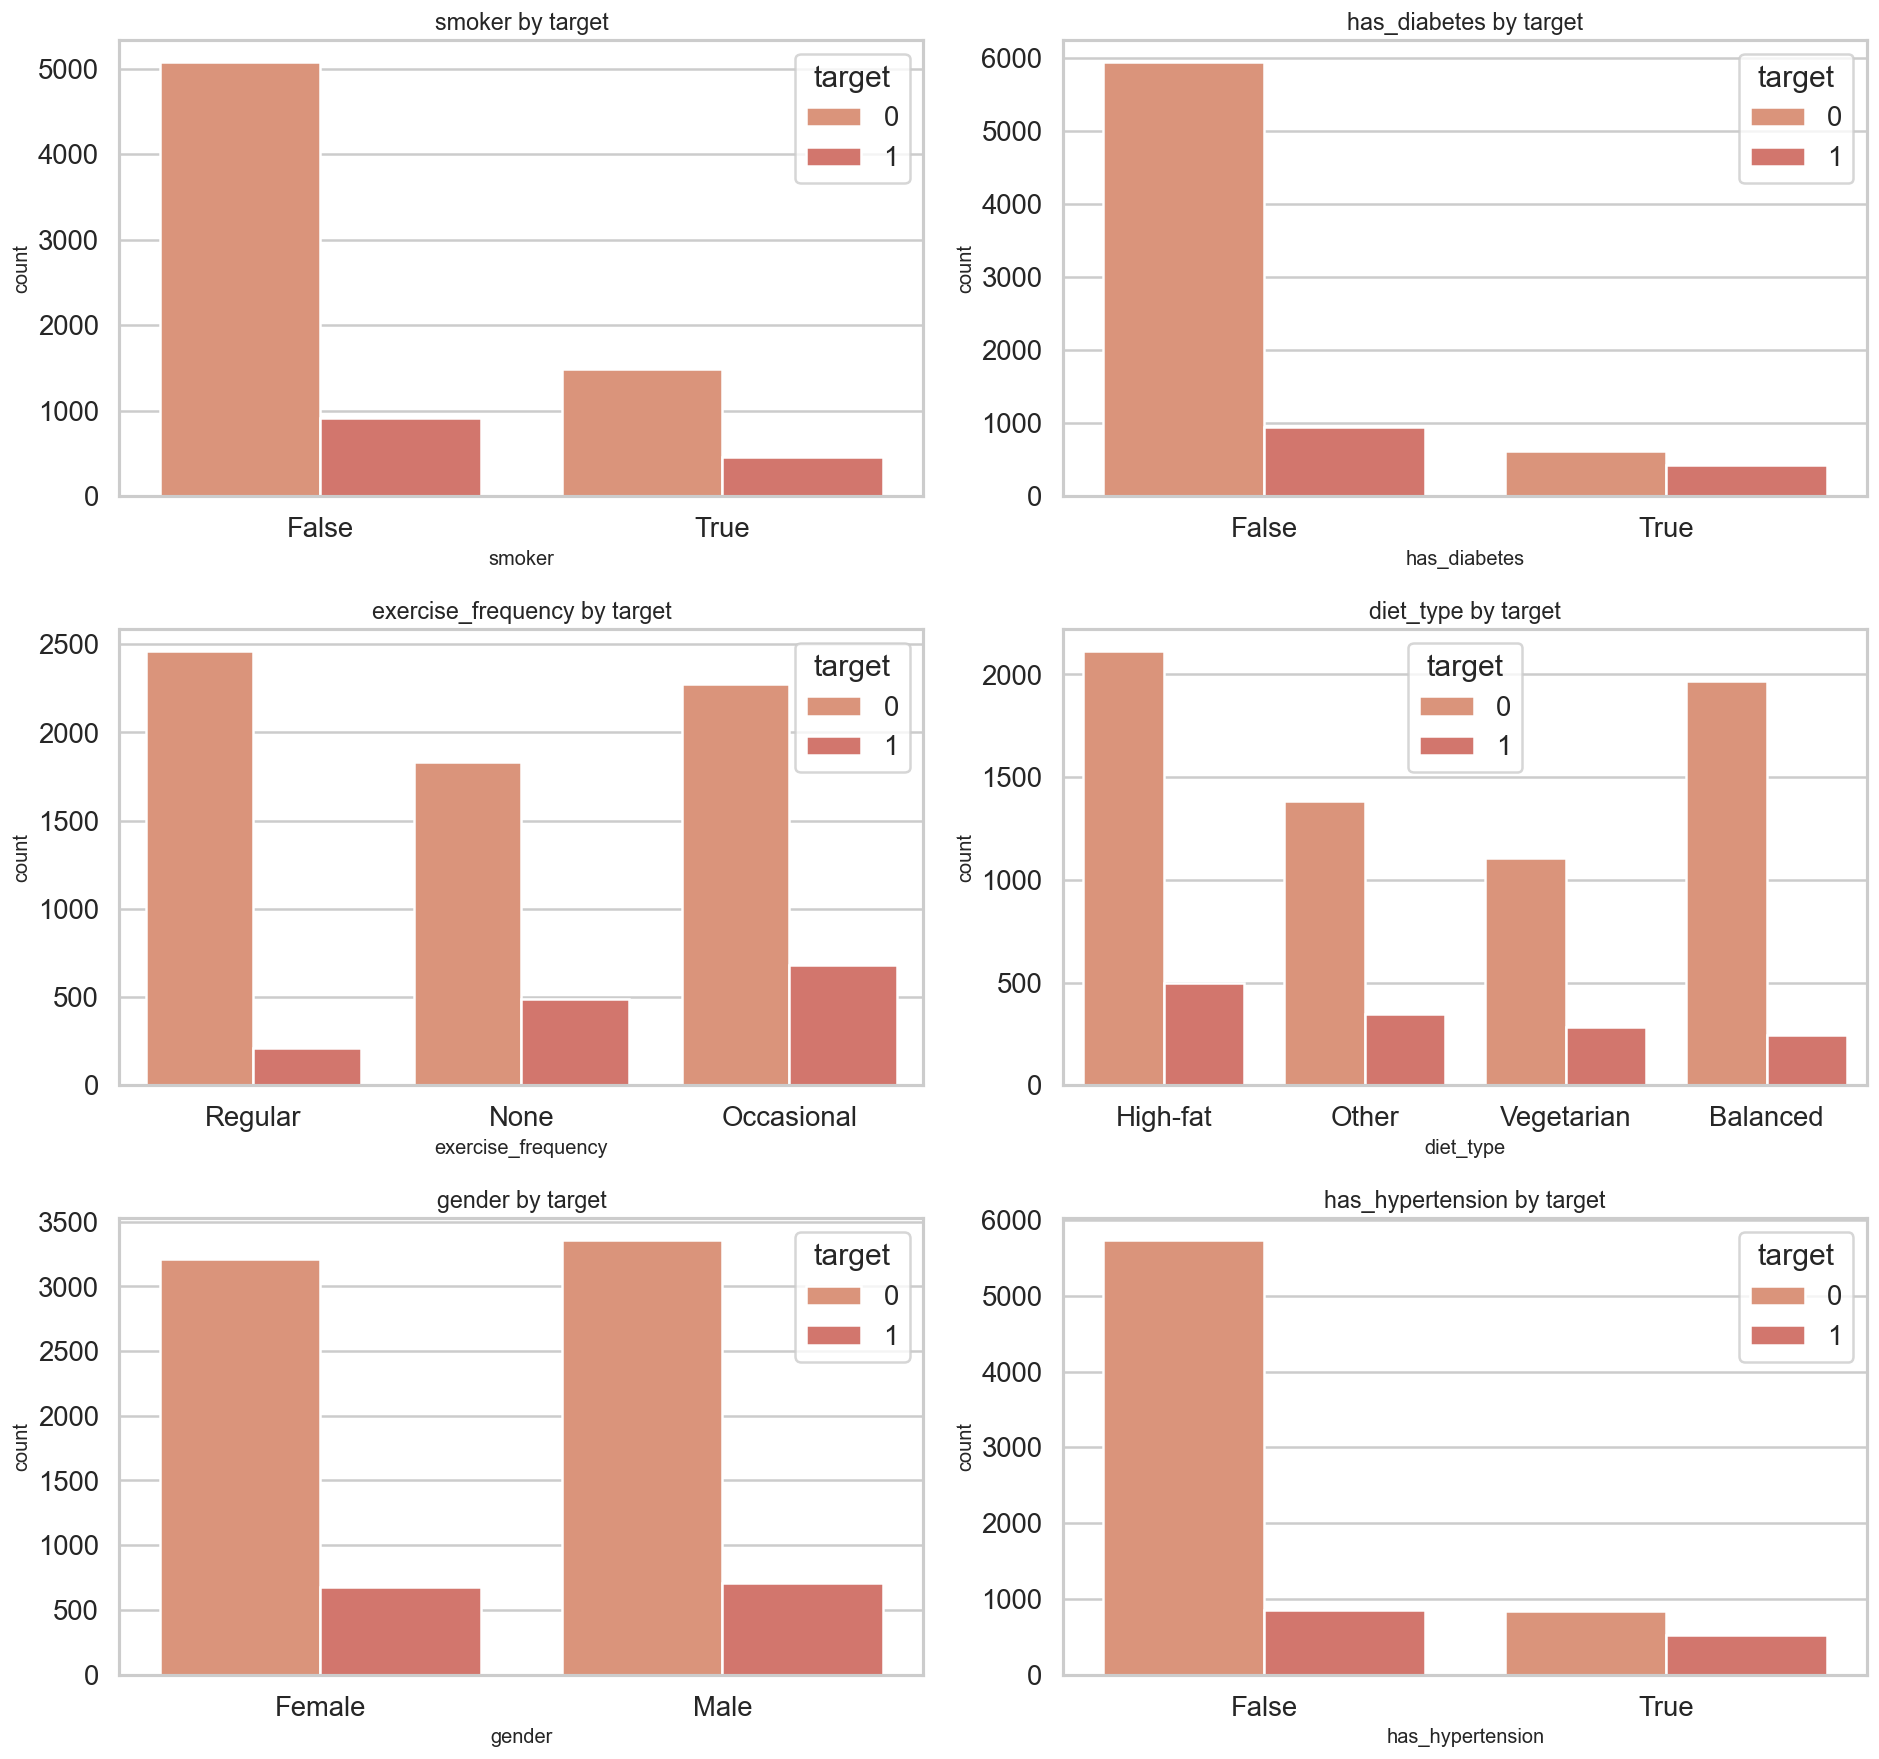

In [186]:
plot_categorical_x_categorical_grid(
    df=df_edit2,
    base_cat_col="target",  
    category_cols=["smoker", "has_diabetes", "exercise_frequency", "diet_type", "gender", "has_hypertension"],
    plot_func=sns.countplot,
    n_plot_cols=2,
    figsize_scale=(8, 5),
)

(<Figure size 1920x1200 with 4 Axes>,
 array([<Axes: title={'center': 'age vs bmi'}, xlabel='age', ylabel='bmi'>,
        <Axes: title={'center': 'weight_kg vs bmi'}, xlabel='weight_kg', ylabel='bmi'>,
        <Axes: title={'center': 'adjusted_weight_kg vs bmi'}, xlabel='adjusted_weight_kg', ylabel='bmi'>,
        <Axes: title={'center': 'length_of_stay vs bmi'}, xlabel='length_of_stay', ylabel='bmi'>],
       dtype=object))

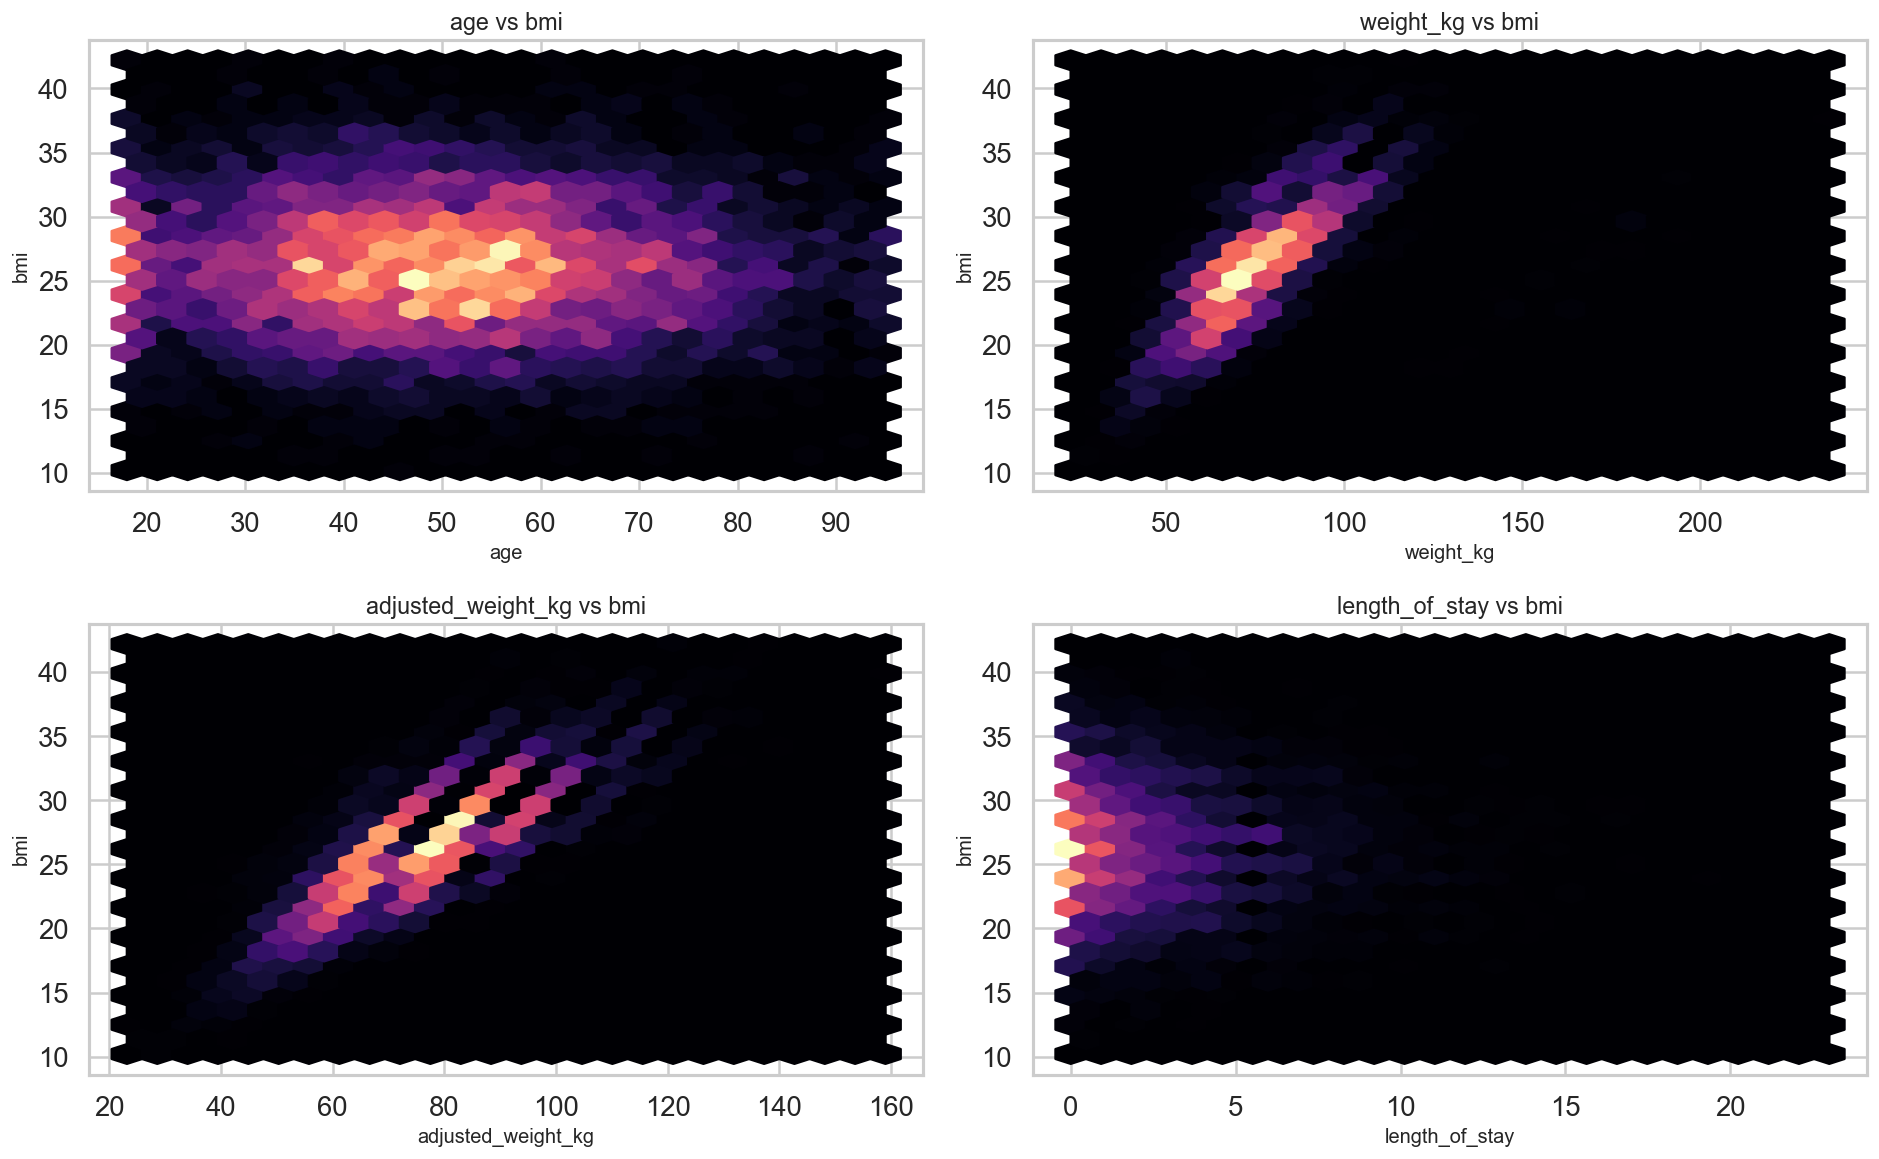

In [187]:
plot_numeric_x_numeric_grid(
    df=df_edit2,
    base_numeric_col="bmi",
    numeric_cols=["age", "weight_kg", "adjusted_weight_kg", "length_of_stay"],
    plot_func='hexbin',
    n_plot_cols=2,
    gridsize=25,
    cmap="magma",
)

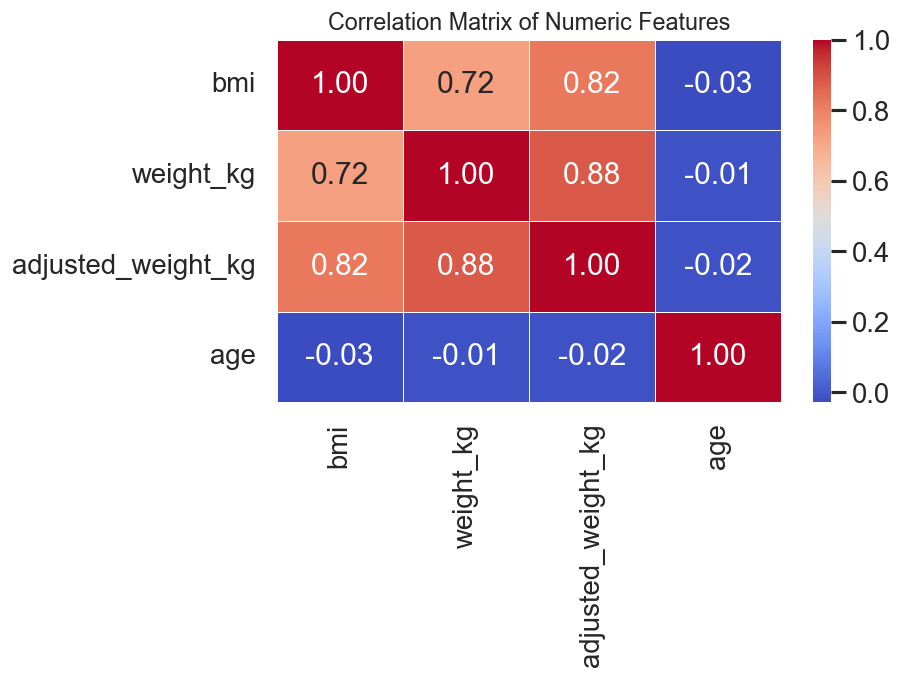

In [189]:
# correlation matrix

numeric_df = df_edit2[measure_cols]

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()


this confirms nothing new but i will do it again with one hot encoded categories in the future probably

(<Figure size 1920x2400 with 7 Axes>,
 array([<Axes: title={'center': 'bmi by gender'}, xlabel='gender', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by smoker'}, xlabel='smoker', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by has_diabetes'}, xlabel='has_diabetes', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by exercise_frequency'}, xlabel='exercise_frequency', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by diet_type'}, xlabel='diet_type', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by hospital_id'}, xlabel='hospital_id', ylabel='bmi'>,
        <Axes: title={'center': 'bmi by type_of_treatment'}, xlabel='type_of_treatment', ylabel='bmi'>],
       dtype=object))

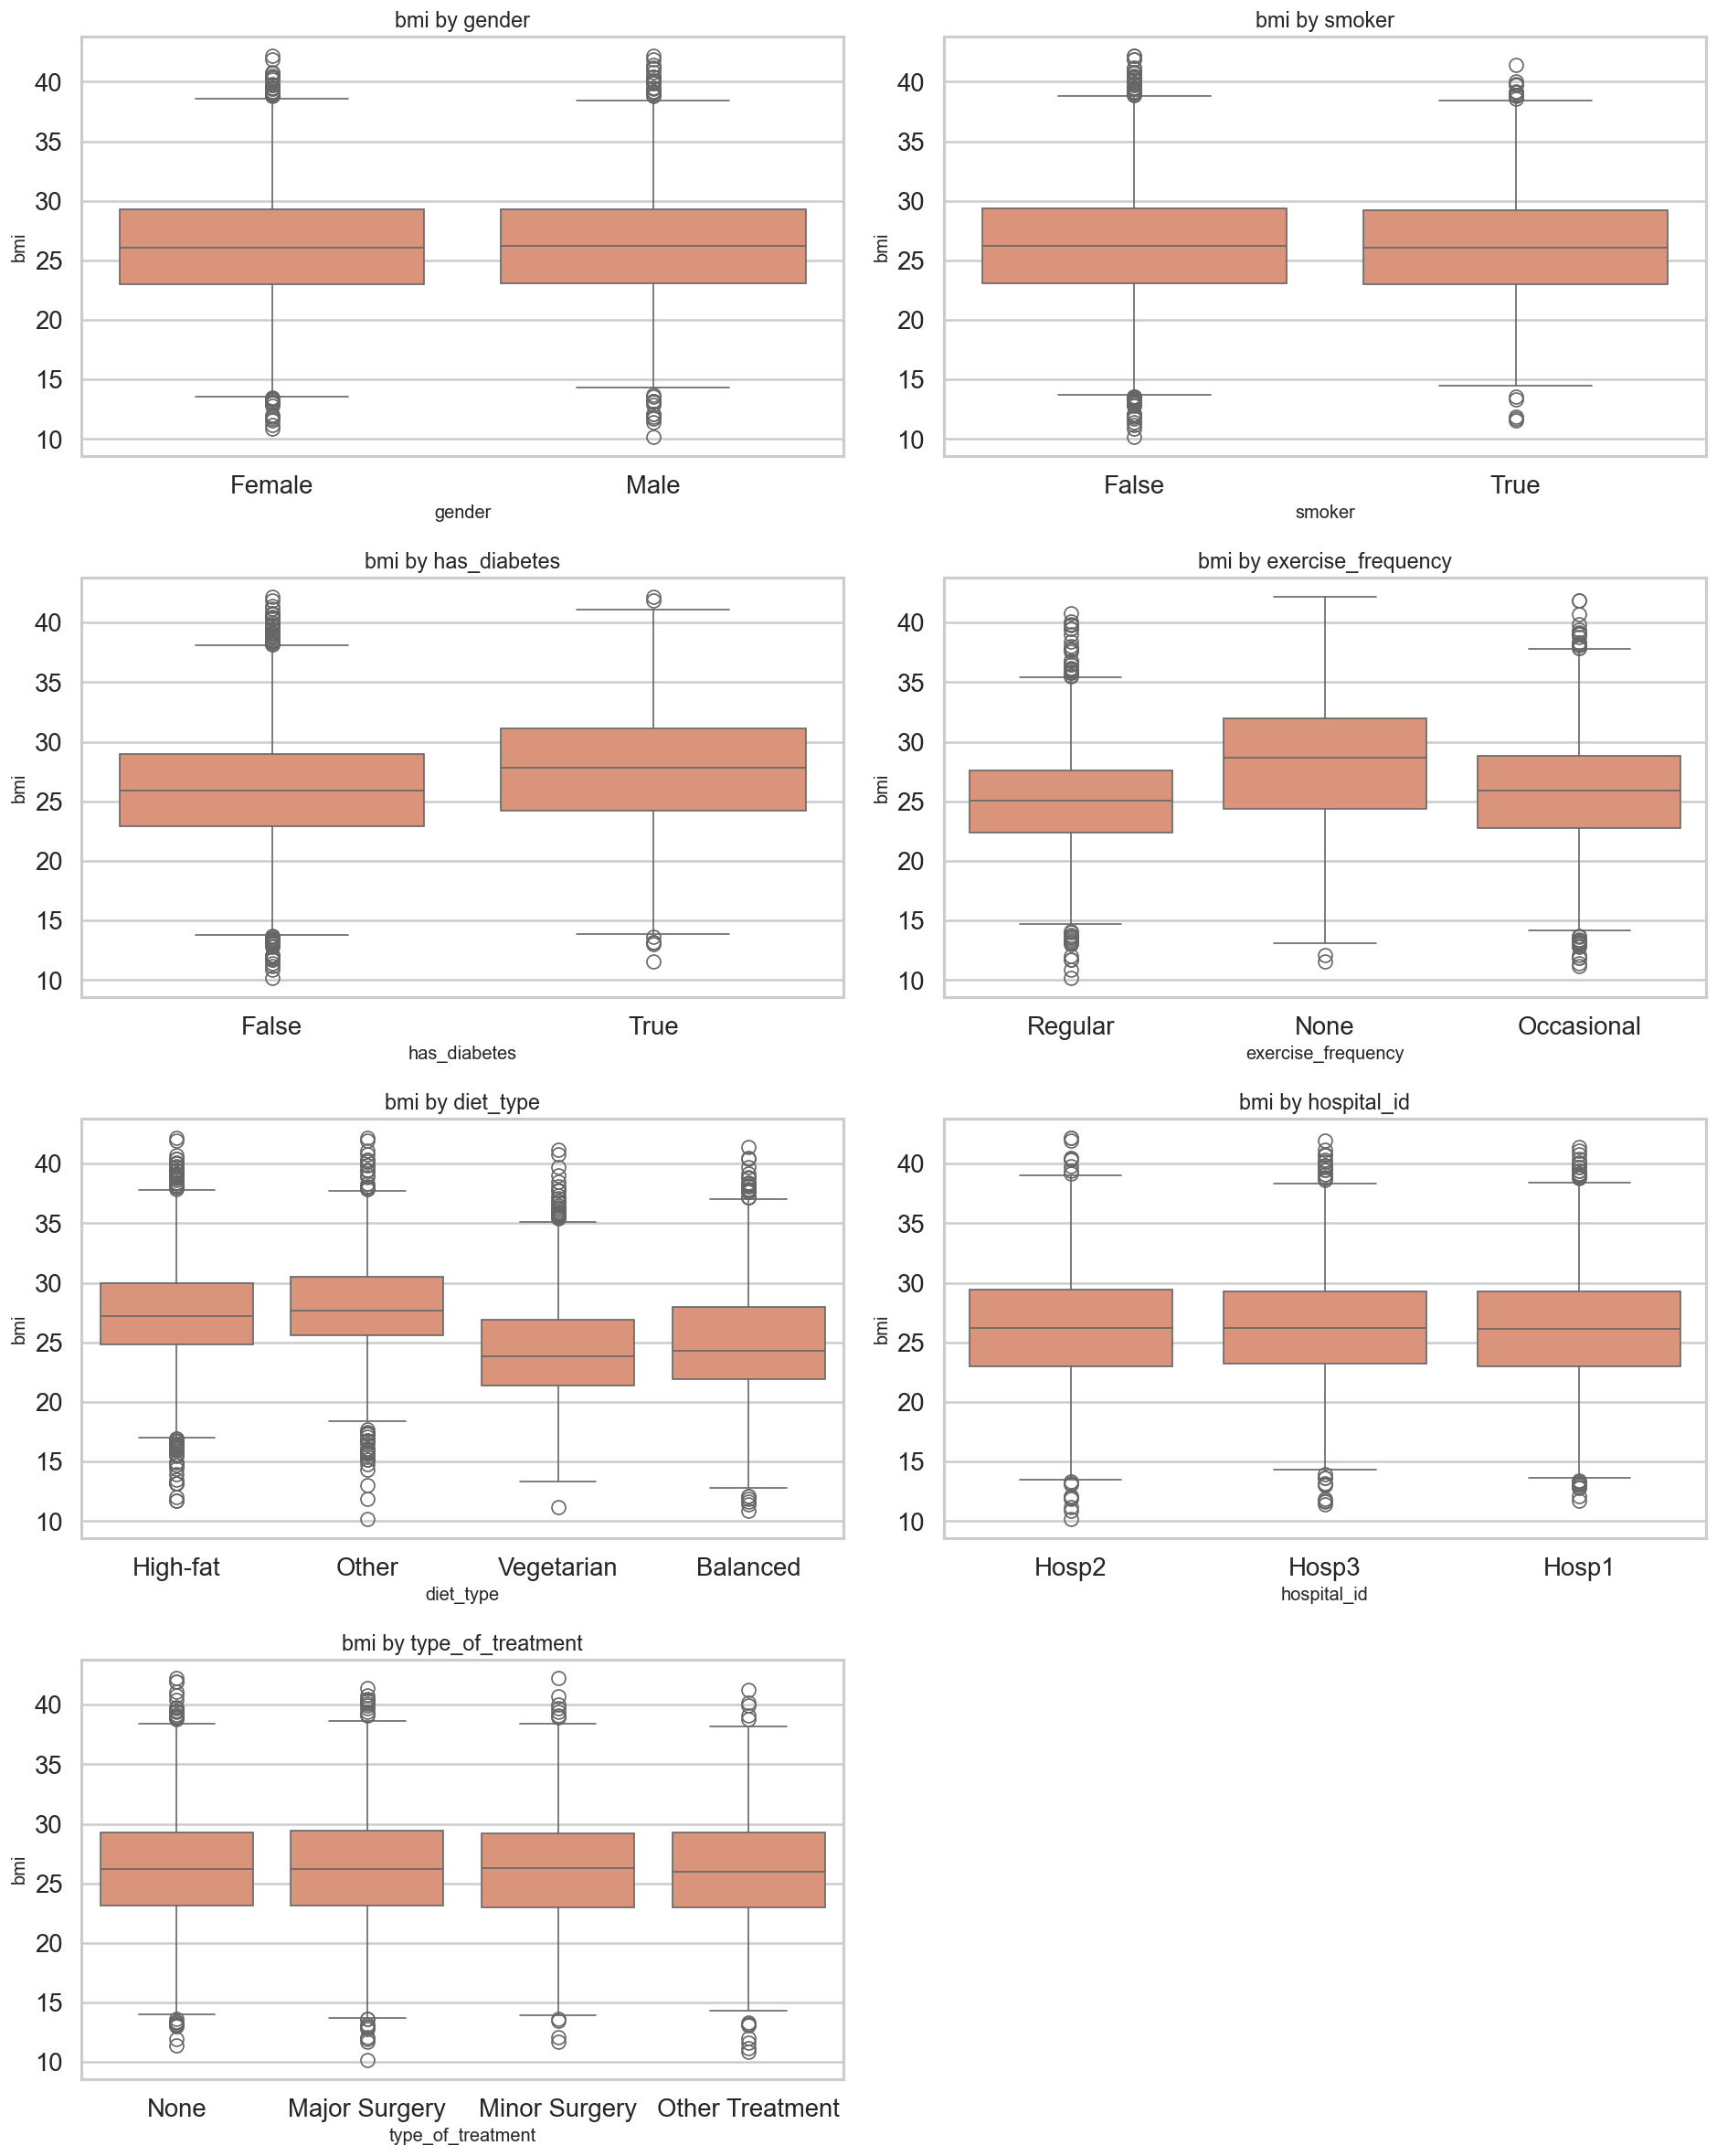

In [174]:
#bmi comparisons
plot_numeric_x_across_categories_grid(
    df=df_edit2,
    numeric_col="bmi",
    category_cols=["gender", "smoker", "has_diabetes", "exercise_frequency", "diet_type","hospital_id", "type_of_treatment" ],
    plot_func=sns.boxplot,
    n_plot_cols=2,
    figsize_scale=(8, 5),
)

(<Figure size 2160x1440 with 7 Axes>,
 array([<Axes: title={'center': 'age by target'}, xlabel='target', ylabel='age'>,
        <Axes: title={'center': 'height_m by target'}, xlabel='target', ylabel='height_m'>,
        <Axes: title={'center': 'bmi by target'}, xlabel='target', ylabel='bmi'>,
        <Axes: title={'center': 'weight_kg by target'}, xlabel='target', ylabel='weight_kg'>,
        <Axes: title={'center': 'adjusted_weight_kg by target'}, xlabel='target', ylabel='adjusted_weight_kg'>,
        <Axes: title={'center': 'number_of_prior_visits by target'}, xlabel='target', ylabel='number_of_prior_visits'>,
        <Axes: title={'center': 'length_of_stay by target'}, xlabel='target', ylabel='length_of_stay'>],
       dtype=object))

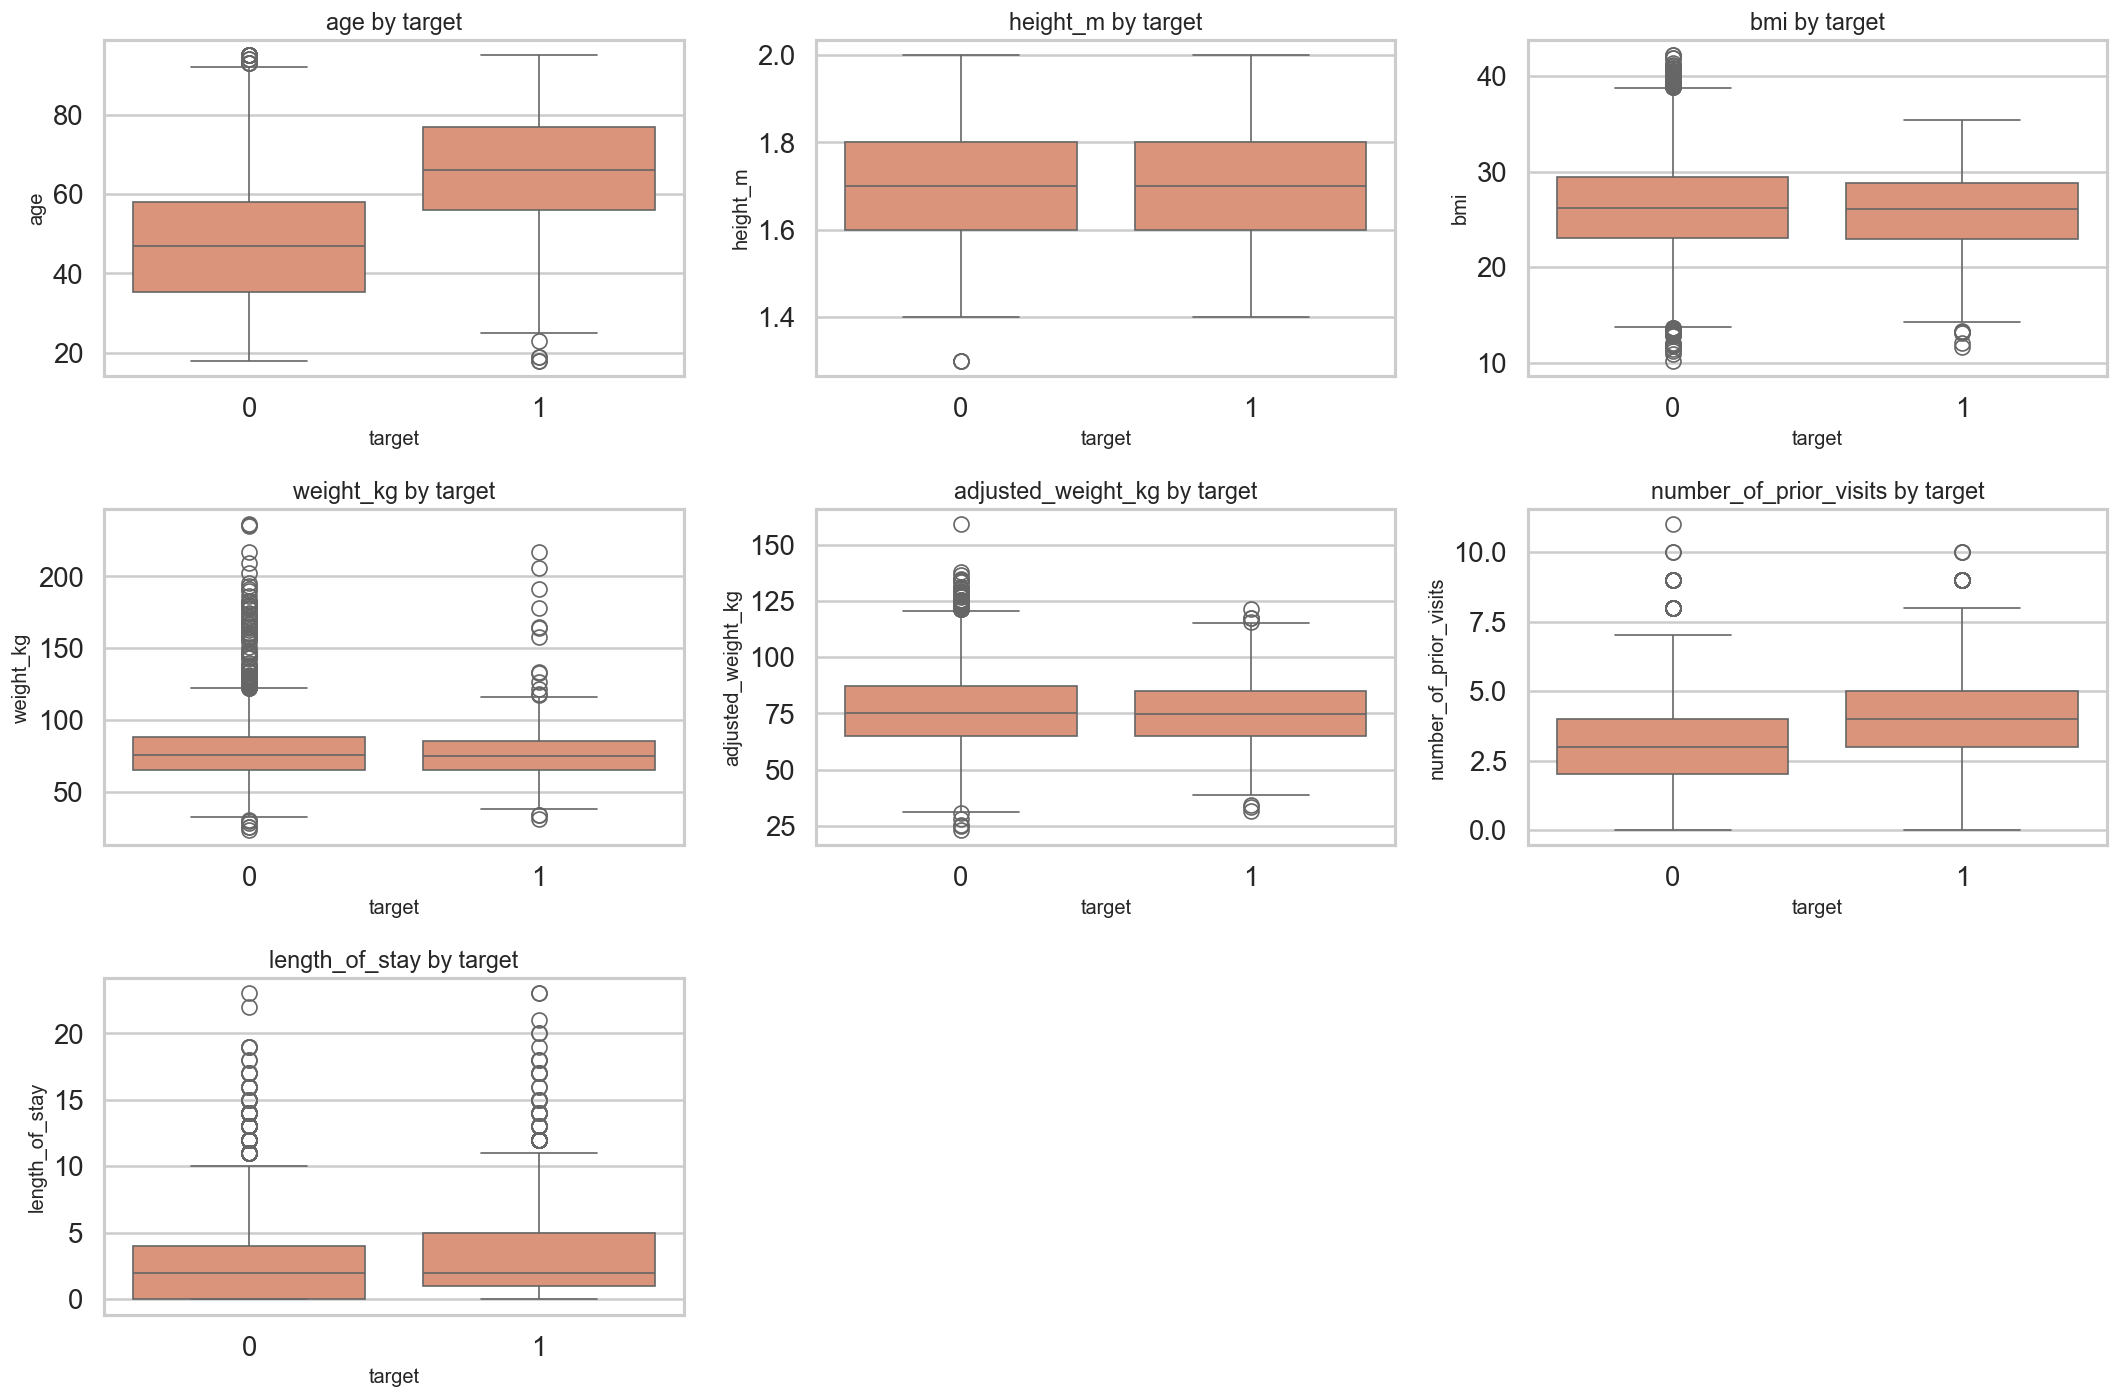

In [193]:
# Plot all numeric columns as boxplots split by target
plot_all_numeric_by_base_category_grid(
    df=df_edit2,
    base_cat_col="target",
    plot_func=sns.boxplot,
    n_plot_cols=3,
    figsize_scale=(6, 4),
)

## **DUPLICATE CHECKING**

In [194]:
df_edit2.duplicated().sum()

np.int64(0)

there are no dupes